# STAGE 1 - LOAD/READ

### contains all important libraries and specific functions 

In [167]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import StandardScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report,precision_score, recall_score, f1_score
from sklearn.neighbors import KNeighborsClassifier
from imblearn.over_sampling import RandomOverSampler
from sklearn.ensemble import RandomForestClassifier

### to read give csv file named "CVD_cleaned.csv.xls"
* actual dataset is real_df in this file.

In [2]:
real_df=pd.read_csv("CVD_cleaned.csv.xls")
real_df

,General_Health,Checkup,Exercise,Heart_Disease,Skin_Cancer,Other_Cancer,Depression,Diabetes,Arthritis,Sex,Age_Category,Height_(cm),Weight_(kg),BMI,Smoking_History,Alcohol_Consumption,Fruit_Consumption,Green_Vegetables_Consumption,FriedPotato_Consumption
0,Poo,Within the past 2 years,No,No,No,No,No,No,Yes,Female,70-74,150,32.66,14.54,Yes,0,30,16,12
1,Very Good,Within the past year,No,Yes,No,No,No,Yes,No,Female,70-74,165,77.11,28.29,No,0,30,0,4
2,Very Good,Within the past year,Yes,No,No,No,No,Yes,No,Female,60-64,163,88.45,33.47,No,4,12,3,16
3,Poor,Within the past year,Yes,Yes,No,No,No,Yes,No,Male,75-79,180,93.44,28.73,No,0,30,30,8
4,Good,Within the past year,No,No,No,No,No,No,No,Male,80+,191,88.45,24.37,Yes,0,8,4,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
308849,Very Good,Within the past year,Yes,No,No,No,No,No,No,m,25-29,168,81.65,29.05,No,4,30,8,0
308850,Fair,Within the past 5 years,Yes,No,No,No,No,Yes,No,Male,65-69,180,69.85,21.48,No,8,15,60,4
308851,Very Good,5 or more years ago,Yes,No,No,No,Yes,"Yes, but female told only during pregnancy",No,Female,30-34,157,61.23,24.69,Yes,4,40,8,4
308852,Very Good,Within the past year,Yes,No,No,No,No,No,No,Male,65-69,183,79.38,23.73,No,3,30,12,0


In [3]:
real_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 308854 entries, 0 to 308853
Data columns (total 19 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   General_Health                308854 non-null  object 
 1   Checkup                       308854 non-null  object 
 2   Exercise                      308854 non-null  object 
 3   Heart_Disease                 308854 non-null  object 
 4   Skin_Cancer                   308854 non-null  object 
 5   Other_Cancer                  308854 non-null  object 
 6   Depression                    308854 non-null  object 
 7   Diabetes                      308854 non-null  object 
 8   Arthritis                     308854 non-null  object 
 9   Sex                           308854 non-null  object 
 10  Age_Category                  308854 non-null  object 
 11  Height_(cm)                   308854 non-null  int64  
 12  Weight_(kg)                   308854 non-nul

In [4]:
real_df.describe().round(3)

,Height_(cm),Weight_(kg),BMI,Alcohol_Consumption,Fruit_Consumption,Green_Vegetables_Consumption,FriedPotato_Consumption
count,308854.000,308854.000,308854.000,308854.000,308854.000,308854.000,308854.000
mean,170.615,83.589,28.626,5.096,29.835,15.110,6.297
std,10.658,21.343,6.522,8.200,24.876,14.926,8.583
min,91.000,24.950,12.020,0.000,0.000,0.000,0.000
25%,163.000,68.040,24.210,0.000,12.000,4.000,2.000
50%,170.000,81.650,27.440,1.000,30.000,12.000,4.000
75%,178.000,95.250,31.850,6.000,30.000,20.000,8.000
max,241.000,293.020,99.330,30.000,120.000,128.000,128.000


### in the dataset the
---
* mean > median (positive skewed)
---
* standard deviation:
  1. medium std() columns -> Height(cm), BMI, Alcohol_Consumption, FriedPotato_Consumption
  2. High std() columns -> Weight(kg), Fruit_Consumption, Green_Vegetables_Consumption
  

# STAGE 2 Basic Analysis

In [5]:
real_df.nunique()

General_Health                     7
Checkup                            5
Exercise                           2
Heart_Disease                      2
Skin_Cancer                        2
Other_Cancer                       2
Depression                         2
Diabetes                           4
Arthritis                          2
Sex                                5
Age_Category                      13
Height_(cm)                       99
Weight_(kg)                      525
BMI                             3654
Smoking_History                    2
Alcohol_Consumption               31
Fruit_Consumption                 77
Green_Vegetables_Consumption      75
FriedPotato_Consumption           69
dtype: int64

### showing all feature with their unique valuse

In [6]:
for col in real_df.columns:
    print(f"{col}\t{real_df[col].unique()}\n")


General_Health	['Poo' 'Very Good' 'Poor' 'Good' 'Fair' 'Excellent' 'poo']

Checkup	['Within the past 2 years' 'Within the past year' '5 or more years ago'
 'Within the past 5 years' 'Never']

Exercise	['No' 'Yes']

Heart_Disease	['No' 'Yes']

Skin_Cancer	['No' 'Yes']

Other_Cancer	['No' 'Yes']

Depression	['No' 'Yes']

Diabetes	['No' 'Yes' 'No, pre-diabetes or borderline diabetes'
 'Yes, but female told only during pregnancy']

Arthritis	['Yes' 'No']

Sex	['Female' 'Male' 'F' 'M' 'm']

Age_Category	['70-74' '60-64' '75-79' '80+' '65-69' '50-54' '45-49' '18-24' '30-34'
 '55-59' '35-39' '40-44' '25-29']

Height_(cm)	[150 165 163 180 191 183 175 160 168 178 152 157 188 185 170 173 155 193
 196 206 198 140 135 145 147 142 201 218 124 203 137 122 216 224 229 151
 177 164 162 156 153 169 167 172 106 190 143 171 154 176 200 146 148 158
 159 187 104 120 107 211 226 182 213  97 184 125 127 234 130 119 132 105
 166 181 186  91 174 208 149  96 197 161  94 103 221 134 144 189 100 179
 117  99 102 

# Stage 3 Fix-Dataset

### find all unique values in specific column

In [7]:
# before removing duplicates
real_df.shape 

(308854, 19)

In [8]:
real_df.duplicated().sum()

80

### removing duplicates 

In [9]:
real_df.drop_duplicates(inplace=True)

In [10]:
# after removing duplicates
real_df.shape

(308774, 19)

## fixing valuse in dataset

* general health

In [11]:
real_df["General_Health"]=real_df["General_Health"].replace({"poo": "Poor"})
real_df["General_Health"]=real_df["General_Health"].replace({"Poo": "Poor"})

In [12]:
real_df['General_Health'].value_counts()

General_Health
Very Good    110351
Good          95355
Excellent     55929
Fair          35808
Poor          11331
Name: count, dtype: int64

* sex column

In [13]:
real_df["Sex"]=real_df["Sex"].replace({"F": "Female"})
real_df["Sex"]=real_df["Sex"].replace({"m": "Male"})
real_df["Sex"]=real_df["Sex"].replace({"M": "Male"})

In [14]:
real_df["Sex"].value_counts()

Sex
Female    160155
Male      148619
Name: count, dtype: int64

* diabetes

In [15]:
real_df["Diabetes"].value_counts()

Diabetes
No                                            259062
Yes                                            40170
No, pre-diabetes or borderline diabetes         6896
Yes, but female told only during pregnancy      2646
Name: count, dtype: int64

In [16]:
real_df["Diabetes"] = real_df["Diabetes"].replace({
    "No, pre-diabetes or borderline diabetes": "No",
    "Yes, but female told only during pregnancy": "Yes"
})


In [17]:
real_df["Diabetes"].value_counts()

Diabetes
No     265958
Yes     42816
Name: count, dtype: int64

* checkup

In [18]:
real_df["Checkup"].value_counts()

Checkup
Within the past year       239295
Within the past 2 years     37210
Within the past 5 years     17442
5 or more years ago         13420
Never                        1407
Name: count, dtype: int64

In [19]:
real_df.nunique()

General_Health                     5
Checkup                            5
Exercise                           2
Heart_Disease                      2
Skin_Cancer                        2
Other_Cancer                       2
Depression                         2
Diabetes                           2
Arthritis                          2
Sex                                2
Age_Category                      13
Height_(cm)                       99
Weight_(kg)                      525
BMI                             3654
Smoking_History                    2
Alcohol_Consumption               31
Fruit_Consumption                 77
Green_Vegetables_Consumption      75
FriedPotato_Consumption           69
dtype: int64

* here i make :
  * General_Health : 7 -> 5 category
  * Diabetes : 4 -> 2
  * Sex : 5 -> 2
    * fix the data which is not properly written

In [20]:
real_df=real_df.drop("Checkup",axis=1)
real_df

,General_Health,Exercise,Heart_Disease,Skin_Cancer,Other_Cancer,Depression,Diabetes,Arthritis,Sex,Age_Category,Height_(cm),Weight_(kg),BMI,Smoking_History,Alcohol_Consumption,Fruit_Consumption,Green_Vegetables_Consumption,FriedPotato_Consumption
0,Poor,No,No,No,No,No,No,Yes,Female,70-74,150,32.66,14.54,Yes,0,30,16,12
1,Very Good,No,Yes,No,No,No,Yes,No,Female,70-74,165,77.11,28.29,No,0,30,0,4
2,Very Good,Yes,No,No,No,No,Yes,No,Female,60-64,163,88.45,33.47,No,4,12,3,16
3,Poor,Yes,Yes,No,No,No,Yes,No,Male,75-79,180,93.44,28.73,No,0,30,30,8
4,Good,No,No,No,No,No,No,No,Male,80+,191,88.45,24.37,Yes,0,8,4,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
308849,Very Good,Yes,No,No,No,No,No,No,Male,25-29,168,81.65,29.05,No,4,30,8,0
308850,Fair,Yes,No,No,No,No,Yes,No,Male,65-69,180,69.85,21.48,No,8,15,60,4
308851,Very Good,Yes,No,No,No,Yes,Yes,No,Female,30-34,157,61.23,24.69,Yes,4,40,8,4
308852,Very Good,Yes,No,No,No,No,No,No,Male,65-69,183,79.38,23.73,No,3,30,12,0


# Stage 4 Encoding of categorical columns

In [21]:
real_df.head(3)

,General_Health,Exercise,Heart_Disease,Skin_Cancer,Other_Cancer,Depression,Diabetes,Arthritis,Sex,Age_Category,Height_(cm),Weight_(kg),BMI,Smoking_History,Alcohol_Consumption,Fruit_Consumption,Green_Vegetables_Consumption,FriedPotato_Consumption
0,Poor,No,No,No,No,No,No,Yes,Female,70-74,150,32.66,14.54,Yes,0,30,16,12
1,Very Good,No,Yes,No,No,No,Yes,No,Female,70-74,165,77.11,28.29,No,0,30,0,4
2,Very Good,Yes,No,No,No,No,Yes,No,Female,60-64,163,88.45,33.47,No,4,12,3,16


### performing encoding on categorical features
---
    Exercise                           2
    Heart_Disease                      2
    Skin_Cancer                        2
    Other_Cancer                       2
    Depression                         2
    Diabetes                           2
    Arthritis                          2
    Sex                                2
    Smoking_History                    2
* one-hot Encoding for upper features because these are yes/no category.
---
    General_Health                     5
    Age_Category                      13
* ordinal Encoding these three features, there is an order. 

In [22]:
one_hot=OneHotEncoder()

* Exercise_enoding

In [23]:
df_exercise=pd.DataFrame(one_hot.fit_transform(real_df[["Exercise"]]).toarray())

In [24]:
df_exercise

,0,1
0,1.0,0.0
1,1.0,0.0
2,0.0,1.0
3,0.0,1.0
4,1.0,0.0
...,...,...
308769,0.0,1.0
308770,0.0,1.0
308771,0.0,1.0
308772,0.0,1.0


In [25]:
df_exercise.drop(0,axis=1,inplace=True)
df_exercise = df_exercise.rename(columns={1: "Exercise_Yes"})

In [26]:
df_exercise

,Exercise_Yes
0,0.0
1,0.0
2,1.0
3,1.0
4,0.0
...,...
308769,1.0
308770,1.0
308771,1.0
308772,1.0


* Heart_disease encoding

In [27]:
df_Heart=pd.DataFrame(one_hot.fit_transform(real_df[["Heart_Disease"]]).toarray())
df_Heart

,0,1
0,1.0,0.0
1,0.0,1.0
2,1.0,0.0
3,0.0,1.0
4,1.0,0.0
...,...,...
308769,1.0,0.0
308770,1.0,0.0
308771,1.0,0.0
308772,1.0,0.0


In [28]:
df_Heart.drop(0,axis=1,inplace=True)

In [29]:
df_Heart=df_Heart.rename(columns={1:"Heart_Disease_Yes"})
df_Heart

,Heart_Disease_Yes
0,0.0
1,1.0
2,0.0
3,1.0
4,0.0
...,...
308769,0.0
308770,0.0
308771,0.0
308772,0.0


* skin cancer encoding 

In [30]:
df_skin=pd.DataFrame(one_hot.fit_transform(real_df[["Skin_Cancer"]]).toarray())
df_skin

,0,1
0,1.0,0.0
1,1.0,0.0
2,1.0,0.0
3,1.0,0.0
4,1.0,0.0
...,...,...
308769,1.0,0.0
308770,1.0,0.0
308771,1.0,0.0
308772,1.0,0.0


In [31]:
df_skin.drop(0,axis=1,inplace=True)

In [32]:
df_skin=df_skin.rename(columns={1:"Skin_Cancer_Yes"})
df_skin

,Skin_Cancer_Yes
0,0.0
1,0.0
2,0.0
3,0.0
4,0.0
...,...
308769,0.0
308770,0.0
308771,0.0
308772,0.0


* other cancer encoding

In [33]:
df_Other_C=pd.DataFrame(one_hot.fit_transform(real_df[["Other_Cancer"]]).toarray())
df_Other_C

,0,1
0,1.0,0.0
1,1.0,0.0
2,1.0,0.0
3,1.0,0.0
4,1.0,0.0
...,...,...
308769,1.0,0.0
308770,1.0,0.0
308771,1.0,0.0
308772,1.0,0.0


In [34]:
df_Other_C.drop(0,axis=1,inplace=True)
df_Other_C=df_Other_C.rename(columns={1:"Other_Cancer_Yes"})
df_Other_C

,Other_Cancer_Yes
0,0.0
1,0.0
2,0.0
3,0.0
4,0.0
...,...
308769,0.0
308770,0.0
308771,0.0
308772,0.0


* depression encoding

In [35]:
df_dep=pd.DataFrame(one_hot.fit_transform(real_df[["Depression"]]).toarray())
df_dep

,0,1
0,1.0,0.0
1,1.0,0.0
2,1.0,0.0
3,1.0,0.0
4,1.0,0.0
...,...,...
308769,1.0,0.0
308770,1.0,0.0
308771,0.0,1.0
308772,1.0,0.0


In [36]:
df_dep.drop(0,axis=1,inplace=True)
df_dep=df_dep.rename(columns={1:"Depression_Yes"})
df_dep

,Depression_Yes
0,0.0
1,0.0
2,0.0
3,0.0
4,0.0
...,...
308769,0.0
308770,0.0
308771,1.0
308772,0.0


* diabetes encoding 

In [37]:
df_dbt=pd.DataFrame(one_hot.fit_transform(real_df[["Diabetes"]]).toarray())
df_dbt

,0,1
0,1.0,0.0
1,0.0,1.0
2,0.0,1.0
3,0.0,1.0
4,1.0,0.0
...,...,...
308769,1.0,0.0
308770,0.0,1.0
308771,0.0,1.0
308772,1.0,0.0


In [38]:
df_dbt.drop(0,axis=1,inplace=True)
df_dbt=df_dbt.rename(columns={1:"Diabetes_Yes"})
df_dbt

,Diabetes_Yes
0,0.0
1,1.0
2,1.0
3,1.0
4,0.0
...,...
308769,0.0
308770,1.0
308771,1.0
308772,0.0


* arthritis encoding

In [39]:
df_Arth=pd.DataFrame(one_hot.fit_transform(real_df[["Arthritis"]]).toarray())
df_Arth

,0,1
0,0.0,1.0
1,1.0,0.0
2,1.0,0.0
3,1.0,0.0
4,1.0,0.0
...,...,...
308769,1.0,0.0
308770,1.0,0.0
308771,1.0,0.0
308772,1.0,0.0


In [40]:
df_Arth.drop(0,axis=1,inplace=True)
df_Arth=df_Arth.rename(columns={1:"Arthritis_Yes"})
df_Arth

,Arthritis_Yes
0,1.0
1,0.0
2,0.0
3,0.0
4,0.0
...,...
308769,0.0
308770,0.0
308771,0.0
308772,0.0


* gender encoding

In [41]:
df_Sex=pd.DataFrame(one_hot.fit_transform(real_df[["Sex"]]).toarray())
df_Sex

,0,1
0,1.0,0.0
1,1.0,0.0
2,1.0,0.0
3,0.0,1.0
4,0.0,1.0
...,...,...
308769,0.0,1.0
308770,0.0,1.0
308771,1.0,0.0
308772,0.0,1.0


In [42]:
df_Sex.drop(0,axis=1,inplace=True)
df_Sex=df_Sex.rename(columns={1:"Male"})
df_Sex

,Male
0,0.0
1,0.0
2,0.0
3,1.0
4,1.0
...,...
308769,1.0
308770,1.0
308771,0.0
308772,1.0


* smoke history encoding

In [43]:
df_Smoke=pd.DataFrame(one_hot.fit_transform(real_df[["Smoking_History"]]).toarray())
df_Smoke

,0,1
0,0.0,1.0
1,1.0,0.0
2,1.0,0.0
3,1.0,0.0
4,0.0,1.0
...,...,...
308769,1.0,0.0
308770,1.0,0.0
308771,0.0,1.0
308772,1.0,0.0


In [44]:
df_Smoke.drop(0,axis=1,inplace=True)
df_Smoke=df_Smoke.rename(columns={1:"Smoking_History_Yes"})
df_Smoke

,Smoking_History_Yes
0,1.0
1,0.0
2,0.0
3,0.0
4,1.0
...,...
308769,0.0
308770,0.0
308771,1.0
308772,0.0


In [45]:
real_df=real_df.reset_index(drop=True)
real_df

,General_Health,Exercise,Heart_Disease,Skin_Cancer,Other_Cancer,Depression,Diabetes,Arthritis,Sex,Age_Category,Height_(cm),Weight_(kg),BMI,Smoking_History,Alcohol_Consumption,Fruit_Consumption,Green_Vegetables_Consumption,FriedPotato_Consumption
0,Poor,No,No,No,No,No,No,Yes,Female,70-74,150,32.66,14.54,Yes,0,30,16,12
1,Very Good,No,Yes,No,No,No,Yes,No,Female,70-74,165,77.11,28.29,No,0,30,0,4
2,Very Good,Yes,No,No,No,No,Yes,No,Female,60-64,163,88.45,33.47,No,4,12,3,16
3,Poor,Yes,Yes,No,No,No,Yes,No,Male,75-79,180,93.44,28.73,No,0,30,30,8
4,Good,No,No,No,No,No,No,No,Male,80+,191,88.45,24.37,Yes,0,8,4,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
308769,Very Good,Yes,No,No,No,No,No,No,Male,25-29,168,81.65,29.05,No,4,30,8,0
308770,Fair,Yes,No,No,No,No,Yes,No,Male,65-69,180,69.85,21.48,No,8,15,60,4
308771,Very Good,Yes,No,No,No,Yes,Yes,No,Female,30-34,157,61.23,24.69,Yes,4,40,8,4
308772,Very Good,Yes,No,No,No,No,No,No,Male,65-69,183,79.38,23.73,No,3,30,12,0


In [46]:
enc_df=real_df.drop(columns=["Exercise","Heart_Disease","Skin_Cancer","Other_Cancer","Depression","Diabetes",
                             "Arthritis","Sex","Smoking_History"],axis=1)
enc_df

,General_Health,Age_Category,Height_(cm),Weight_(kg),BMI,Alcohol_Consumption,Fruit_Consumption,Green_Vegetables_Consumption,FriedPotato_Consumption
0,Poor,70-74,150,32.66,14.54,0,30,16,12
1,Very Good,70-74,165,77.11,28.29,0,30,0,4
2,Very Good,60-64,163,88.45,33.47,4,12,3,16
3,Poor,75-79,180,93.44,28.73,0,30,30,8
4,Good,80+,191,88.45,24.37,0,8,4,0
...,...,...,...,...,...,...,...,...,...
308769,Very Good,25-29,168,81.65,29.05,4,30,8,0
308770,Fair,65-69,180,69.85,21.48,8,15,60,4
308771,Very Good,30-34,157,61.23,24.69,4,40,8,4
308772,Very Good,65-69,183,79.38,23.73,3,30,12,0


* Drop columns which are encoded by one hot encoder from enc_df to add encoded columns.

In [47]:
enc_df=pd.concat([enc_df,df_exercise,df_Heart,df_skin,df_Other_C,df_dep,df_dbt,df_Arth,df_Sex,df_Smoke],axis=1)
enc_df

,General_Health,Age_Category,Height_(cm),Weight_(kg),BMI,Alcohol_Consumption,Fruit_Consumption,Green_Vegetables_Consumption,FriedPotato_Consumption,Exercise_Yes,Heart_Disease_Yes,Skin_Cancer_Yes,Other_Cancer_Yes,Depression_Yes,Diabetes_Yes,Arthritis_Yes,Male,Smoking_History_Yes
0,Poor,70-74,150,32.66,14.54,0,30,16,12,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
1,Very Good,70-74,165,77.11,28.29,0,30,0,4,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,Very Good,60-64,163,88.45,33.47,4,12,3,16,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
3,Poor,75-79,180,93.44,28.73,0,30,30,8,1.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
4,Good,80+,191,88.45,24.37,0,8,4,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
308769,Very Good,25-29,168,81.65,29.05,4,30,8,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
308770,Fair,65-69,180,69.85,21.48,8,15,60,4,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
308771,Very Good,30-34,157,61.23,24.69,4,40,8,4,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0
308772,Very Good,65-69,183,79.38,23.73,3,30,12,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


* enc_df is created for storing encoded data
* the ..YES columns have two values only which shows:
   * like Diabetes_Yes if there is 1 means he have diabetes and 0 means he have not diabetes 

* generaal_health ordinal encoding

In [48]:
ord_enc=OrdinalEncoder(categories=[["Poor","Fair","Good","Very Good","Excellent"]])

In [49]:
df_GH=pd.DataFrame(ord_enc.fit_transform(real_df[["General_Health"]]))
df_GH

,0
0,0.0
1,3.0
2,3.0
3,0.0
4,2.0
...,...
308769,3.0
308770,1.0
308771,3.0
308772,3.0


In [50]:
df_GH=df_GH.rename(columns={0:"General_Health"})
df_GH

,General_Health
0,0.0
1,3.0
2,3.0
3,0.0
4,2.0
...,...
308769,3.0
308770,1.0
308771,3.0
308772,3.0


In [51]:
df_GH["General_Health"].unique()

array([0., 3., 2., 1., 4.])

* checkup ordinal encoding

* age_category ordinal encoding

In [52]:
ord_enc_age=OrdinalEncoder(categories=[["18-24","25-29","30-34","35-39","40-44","45-49","50-54",
                                        "55-59","60-64","65-69","70-74","75-79","80+"]])

In [53]:
df_age=pd.DataFrame(ord_enc_age.fit_transform(real_df[["Age_Category"]]))
df_age

,0
0,10.0
1,10.0
2,8.0
3,11.0
4,12.0
...,...
308769,1.0
308770,9.0
308771,2.0
308772,9.0


In [54]:
df_age=df_age.rename(columns={0:"Age_Category"})
df_age

,Age_Category
0,10.0
1,10.0
2,8.0
3,11.0
4,12.0
...,...
308769,1.0
308770,9.0
308771,2.0
308772,9.0


In [55]:
df_age["Age_Category"].unique()

array([10.,  8., 11., 12.,  9.,  6.,  5.,  0.,  2.,  7.,  3.,  4.,  1.])

### ordinal encoding
* general_health = { Poor:0, fair:1, good:2, very good:3, excellent:4 }
* checkup = { in past 1_year:0, in past 2_year:1, in past 5_year:2, 5+ year:3, never:4})
* age_category = { 18-24:0, 24-29:1, 30-34:2, 35-39:3, 40-44:4, 45-49:5, 50-54:6, 55-59:7, 60-64:8, 65-69:9, 70-74:10, 75-79:11, 80+:12}

In [56]:
enc_df

,General_Health,Age_Category,Height_(cm),Weight_(kg),BMI,Alcohol_Consumption,Fruit_Consumption,Green_Vegetables_Consumption,FriedPotato_Consumption,Exercise_Yes,Heart_Disease_Yes,Skin_Cancer_Yes,Other_Cancer_Yes,Depression_Yes,Diabetes_Yes,Arthritis_Yes,Male,Smoking_History_Yes
0,Poor,70-74,150,32.66,14.54,0,30,16,12,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
1,Very Good,70-74,165,77.11,28.29,0,30,0,4,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,Very Good,60-64,163,88.45,33.47,4,12,3,16,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
3,Poor,75-79,180,93.44,28.73,0,30,30,8,1.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
4,Good,80+,191,88.45,24.37,0,8,4,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
308769,Very Good,25-29,168,81.65,29.05,4,30,8,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
308770,Fair,65-69,180,69.85,21.48,8,15,60,4,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
308771,Very Good,30-34,157,61.23,24.69,4,40,8,4,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0
308772,Very Good,65-69,183,79.38,23.73,3,30,12,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [57]:
enc_df=enc_df.drop(["General_Health","Age_Category"],axis=1)
enc_df

,Height_(cm),Weight_(kg),BMI,Alcohol_Consumption,Fruit_Consumption,Green_Vegetables_Consumption,FriedPotato_Consumption,Exercise_Yes,Heart_Disease_Yes,Skin_Cancer_Yes,Other_Cancer_Yes,Depression_Yes,Diabetes_Yes,Arthritis_Yes,Male,Smoking_History_Yes
0,150,32.66,14.54,0,30,16,12,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
1,165,77.11,28.29,0,30,0,4,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,163,88.45,33.47,4,12,3,16,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
3,180,93.44,28.73,0,30,30,8,1.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
4,191,88.45,24.37,0,8,4,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
308769,168,81.65,29.05,4,30,8,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
308770,180,69.85,21.48,8,15,60,4,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
308771,157,61.23,24.69,4,40,8,4,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0
308772,183,79.38,23.73,3,30,12,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [58]:
enc_df=pd.concat([enc_df,df_GH,df_age],axis=1)
enc_df

,Height_(cm),Weight_(kg),BMI,Alcohol_Consumption,Fruit_Consumption,Green_Vegetables_Consumption,FriedPotato_Consumption,Exercise_Yes,Heart_Disease_Yes,Skin_Cancer_Yes,Other_Cancer_Yes,Depression_Yes,Diabetes_Yes,Arthritis_Yes,Male,Smoking_History_Yes,General_Health,Age_Category
0,150,32.66,14.54,0,30,16,12,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,10.0
1,165,77.11,28.29,0,30,0,4,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,3.0,10.0
2,163,88.45,33.47,4,12,3,16,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,3.0,8.0
3,180,93.44,28.73,0,30,30,8,1.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,11.0
4,191,88.45,24.37,0,8,4,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,2.0,12.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
308769,168,81.65,29.05,4,30,8,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,3.0,1.0
308770,180,69.85,21.48,8,15,60,4,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,9.0
308771,157,61.23,24.69,4,40,8,4,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,3.0,2.0
308772,183,79.38,23.73,3,30,12,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,3.0,9.0


In [59]:
enc_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 308774 entries, 0 to 308773
Data columns (total 18 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   Height_(cm)                   308774 non-null  int64  
 1   Weight_(kg)                   308774 non-null  float64
 2   BMI                           308774 non-null  float64
 3   Alcohol_Consumption           308774 non-null  int64  
 4   Fruit_Consumption             308774 non-null  int64  
 5   Green_Vegetables_Consumption  308774 non-null  int64  
 6   FriedPotato_Consumption       308774 non-null  int64  
 7   Exercise_Yes                  308774 non-null  float64
 8   Heart_Disease_Yes             308774 non-null  float64
 9   Skin_Cancer_Yes               308774 non-null  float64
 10  Other_Cancer_Yes              308774 non-null  float64
 11  Depression_Yes                308774 non-null  float64
 12  Diabetes_Yes                  308774 non-nul

* After one-hot and ordinal encoding my our datset looks like this..
* all are numerical features.
* finally encoded dataframe is ---> enc_df
  

# Stage 5 handling outliers

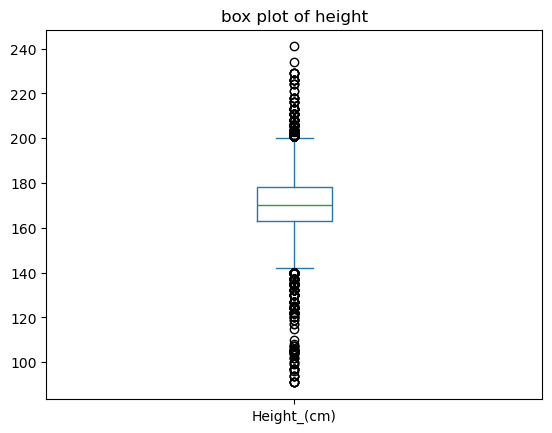

In [60]:
enc_df["Height_(cm)"].plot(kind="box")
plt.title("box plot of height")
plt.show()

Text(0.5, 1.0, 'weight boxplot')

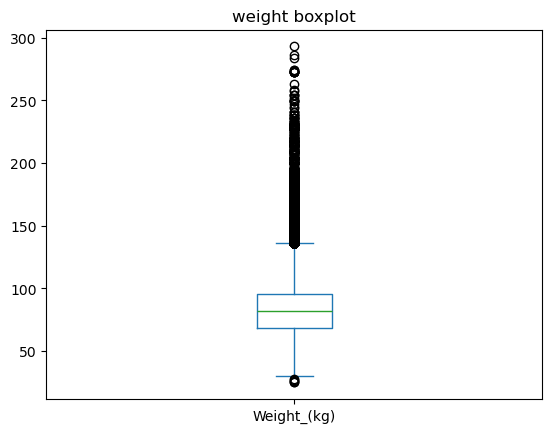

In [61]:
enc_df["Weight_(kg)"].plot(kind="box")
plt.title("weight boxplot")

Text(0.5, 1.0, 'BMI boxplot')

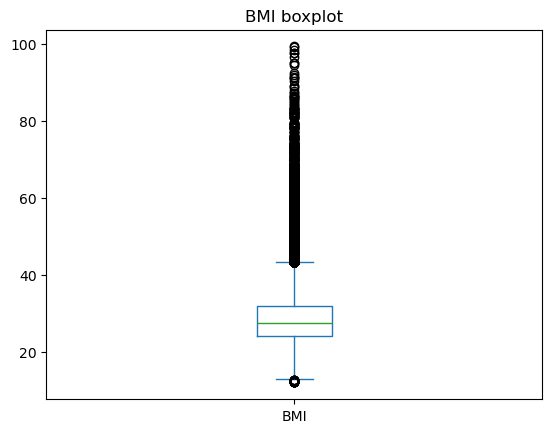

In [62]:
enc_df["BMI"].plot(kind="box")
plt.title("BMI boxplot")

Text(0.5, 1.0, 'Alcohol_Consumption boxplot')

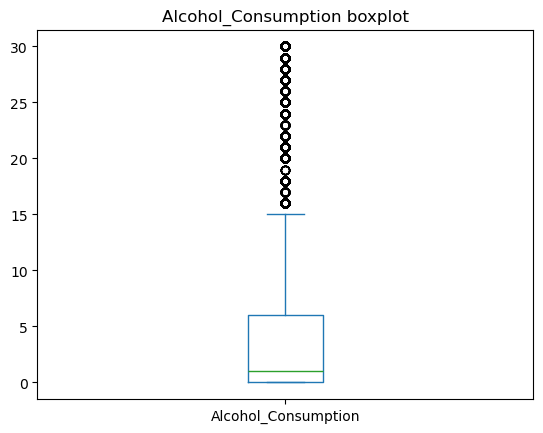

In [63]:
enc_df["Alcohol_Consumption"].plot(kind="box")
plt.title("Alcohol_Consumption boxplot")

Text(0.5, 1.0, 'Fruit_consuption boxplot')

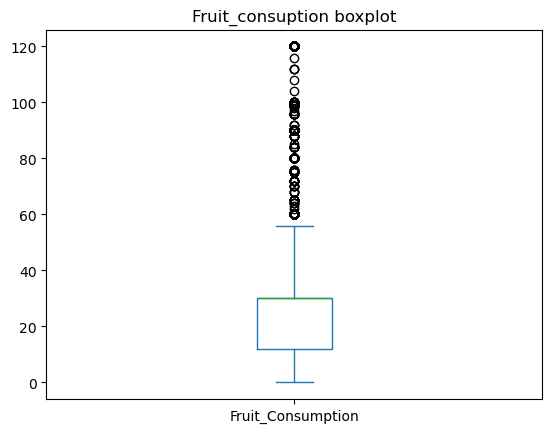

In [64]:
enc_df["Fruit_Consumption"].plot(kind="box")
plt.title("Fruit_consuption boxplot")

Text(0.5, 1.0, 'Green_Vegetables_Consumption boxplot')

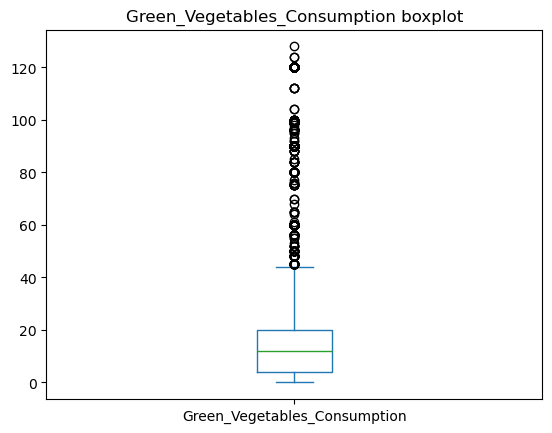

In [65]:
enc_df["Green_Vegetables_Consumption"].plot(kind="box")
plt.title("Green_Vegetables_Consumption boxplot")

Text(0.5, 1.0, 'FriedPotato_Consumption boxplot')

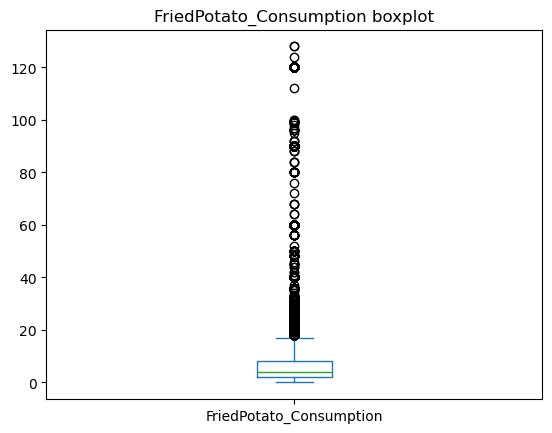

In [66]:
enc_df["FriedPotato_Consumption"].plot(kind="box")
plt.title("FriedPotato_Consumption boxplot")

* fried patato consumption: upper outliers.
* Green_Vegetables_Consumption : upper outliers.
* fruit consumption : upper outliers.
* alcohol consumption: upper outliers.
* BMI , Height and Weight have both upper and lower outliers.

### IQR METHOD for outliers removing

In [67]:
enc_df=enc_df.rename(columns={"Weight_(kg)":"Weight","Height_(cm)":"height"})
enc_df.head(3)

,height,Weight,BMI,Alcohol_Consumption,Fruit_Consumption,Green_Vegetables_Consumption,FriedPotato_Consumption,Exercise_Yes,Heart_Disease_Yes,Skin_Cancer_Yes,Other_Cancer_Yes,Depression_Yes,Diabetes_Yes,Arthritis_Yes,Male,Smoking_History_Yes,General_Health,Age_Category
0,150,32.66,14.54,0,30,16,12,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,10.0
1,165,77.11,28.29,0,30,0,4,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,3.0,10.0
2,163,88.45,33.47,4,12,3,16,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,3.0,8.0


In [68]:
Q1=enc_df.quantile(0.25)
Q1

height                          163.00
Weight                           68.04
BMI                              24.21
Alcohol_Consumption               0.00
Fruit_Consumption                12.00
Green_Vegetables_Consumption      4.00
FriedPotato_Consumption           2.00
Exercise_Yes                      1.00
Heart_Disease_Yes                 0.00
Skin_Cancer_Yes                   0.00
Other_Cancer_Yes                  0.00
Depression_Yes                    0.00
Diabetes_Yes                      0.00
Arthritis_Yes                     0.00
Male                              0.00
Smoking_History_Yes               0.00
General_Health                    2.00
Age_Category                      4.00
Name: 0.25, dtype: float64

In [69]:
Q3=enc_df.quantile(0.75)
Q3

height                          178.00
Weight                           95.25
BMI                              31.85
Alcohol_Consumption               6.00
Fruit_Consumption                30.00
Green_Vegetables_Consumption     20.00
FriedPotato_Consumption           8.00
Exercise_Yes                      1.00
Heart_Disease_Yes                 0.00
Skin_Cancer_Yes                   0.00
Other_Cancer_Yes                  0.00
Depression_Yes                    0.00
Diabetes_Yes                      0.00
Arthritis_Yes                     1.00
Male                              1.00
Smoking_History_Yes               1.00
General_Health                    3.00
Age_Category                      9.00
Name: 0.75, dtype: float64

In [70]:
IQR=Q3-Q1
IQR

height                          15.00
Weight                          27.21
BMI                              7.64
Alcohol_Consumption              6.00
Fruit_Consumption               18.00
Green_Vegetables_Consumption    16.00
FriedPotato_Consumption          6.00
Exercise_Yes                     0.00
Heart_Disease_Yes                0.00
Skin_Cancer_Yes                  0.00
Other_Cancer_Yes                 0.00
Depression_Yes                   0.00
Diabetes_Yes                     0.00
Arthritis_Yes                    1.00
Male                             1.00
Smoking_History_Yes              1.00
General_Health                   1.00
Age_Category                     5.00
dtype: float64

<Axes: >

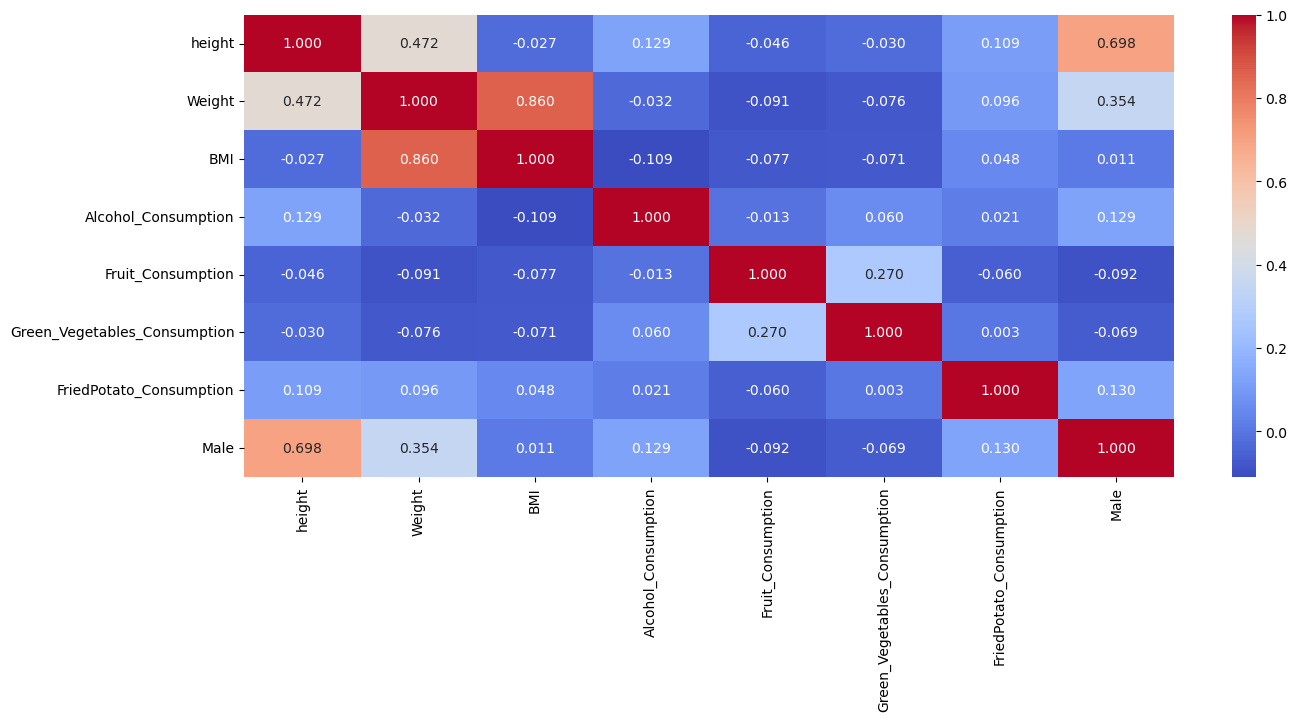

In [71]:
plt.figure(figsize=(15,6))
sns.heatmap(enc_df[["height","Weight","BMI","Alcohol_Consumption","Fruit_Consumption","Green_Vegetables_Consumption","FriedPotato_Consumption","Male"]].corr(),
            annot=True, fmt=".3f", cmap="coolwarm")


* there is slightly high correlation between (male-height), (weight-bmi)

In [72]:
enc_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 308774 entries, 0 to 308773
Data columns (total 18 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   height                        308774 non-null  int64  
 1   Weight                        308774 non-null  float64
 2   BMI                           308774 non-null  float64
 3   Alcohol_Consumption           308774 non-null  int64  
 4   Fruit_Consumption             308774 non-null  int64  
 5   Green_Vegetables_Consumption  308774 non-null  int64  
 6   FriedPotato_Consumption       308774 non-null  int64  
 7   Exercise_Yes                  308774 non-null  float64
 8   Heart_Disease_Yes             308774 non-null  float64
 9   Skin_Cancer_Yes               308774 non-null  float64
 10  Other_Cancer_Yes              308774 non-null  float64
 11  Depression_Yes                308774 non-null  float64
 12  Diabetes_Yes                  308774 non-nul

### Weight

In [73]:
low_q1_weight=Q1.Weight-1.5*IQR.Weight


In [74]:
low_q1_weight

27.225000000000016

In [75]:
c_df=enc_df.drop(enc_df[enc_df["Weight"] < low_q1_weight].index)
c_df

,height,Weight,BMI,Alcohol_Consumption,Fruit_Consumption,Green_Vegetables_Consumption,FriedPotato_Consumption,Exercise_Yes,Heart_Disease_Yes,Skin_Cancer_Yes,Other_Cancer_Yes,Depression_Yes,Diabetes_Yes,Arthritis_Yes,Male,Smoking_History_Yes,General_Health,Age_Category
0,150,32.66,14.54,0,30,16,12,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,10.0
1,165,77.11,28.29,0,30,0,4,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,3.0,10.0
2,163,88.45,33.47,4,12,3,16,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,3.0,8.0
3,180,93.44,28.73,0,30,30,8,1.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,11.0
4,191,88.45,24.37,0,8,4,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,2.0,12.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
308769,168,81.65,29.05,4,30,8,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,3.0,1.0
308770,180,69.85,21.48,8,15,60,4,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,9.0
308771,157,61.23,24.69,4,40,8,4,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,3.0,2.0
308772,183,79.38,23.73,3,30,12,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,3.0,9.0


In [76]:
high_q3_weight=Q3.Weight + 1.5 * IQR.Weight
high_q3_weight

136.065

In [77]:
c_df=enc_df.drop(enc_df[enc_df["Weight"] > high_q3_weight]. index)
c_df

,height,Weight,BMI,Alcohol_Consumption,Fruit_Consumption,Green_Vegetables_Consumption,FriedPotato_Consumption,Exercise_Yes,Heart_Disease_Yes,Skin_Cancer_Yes,Other_Cancer_Yes,Depression_Yes,Diabetes_Yes,Arthritis_Yes,Male,Smoking_History_Yes,General_Health,Age_Category
0,150,32.66,14.54,0,30,16,12,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,10.0
1,165,77.11,28.29,0,30,0,4,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,3.0,10.0
2,163,88.45,33.47,4,12,3,16,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,3.0,8.0
3,180,93.44,28.73,0,30,30,8,1.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,11.0
4,191,88.45,24.37,0,8,4,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,2.0,12.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
308769,168,81.65,29.05,4,30,8,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,3.0,1.0
308770,180,69.85,21.48,8,15,60,4,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,9.0
308771,157,61.23,24.69,4,40,8,4,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,3.0,2.0
308772,183,79.38,23.73,3,30,12,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,3.0,9.0


Text(0.5, 1.0, 'weight')

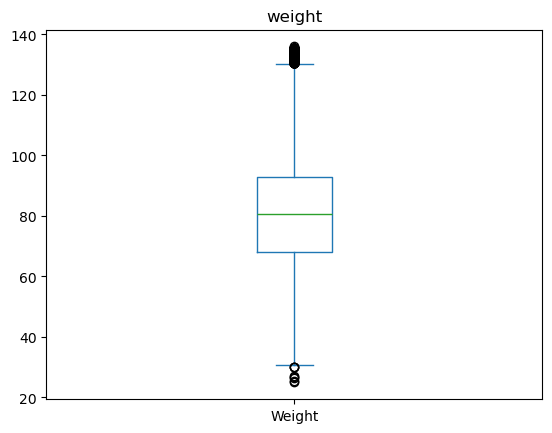

In [78]:
c_df["Weight"].plot(kind="box")
plt.title("weight")

*  outlier's of weight column removed now the shape of rows is 308774 -> 301453.

### height

In [79]:
low_q1_height= Q1.height - 1.5 * IQR.height
low_q1_height

140.5

In [80]:
c_df=c_df.drop(c_df[c_df["height"] < low_q1_height].index)
c_df

,height,Weight,BMI,Alcohol_Consumption,Fruit_Consumption,Green_Vegetables_Consumption,FriedPotato_Consumption,Exercise_Yes,Heart_Disease_Yes,Skin_Cancer_Yes,Other_Cancer_Yes,Depression_Yes,Diabetes_Yes,Arthritis_Yes,Male,Smoking_History_Yes,General_Health,Age_Category
0,150,32.66,14.54,0,30,16,12,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,10.0
1,165,77.11,28.29,0,30,0,4,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,3.0,10.0
2,163,88.45,33.47,4,12,3,16,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,3.0,8.0
3,180,93.44,28.73,0,30,30,8,1.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,11.0
4,191,88.45,24.37,0,8,4,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,2.0,12.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
308769,168,81.65,29.05,4,30,8,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,3.0,1.0
308770,180,69.85,21.48,8,15,60,4,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,9.0
308771,157,61.23,24.69,4,40,8,4,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,3.0,2.0
308772,183,79.38,23.73,3,30,12,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,3.0,9.0


In [81]:
high_q3_height = Q3.height +1.5 *IQR.height
high_q3_height

200.5

In [82]:
c_df=c_df.drop(c_df[c_df["height"] > high_q3_height].index)

In [83]:
c_df

,height,Weight,BMI,Alcohol_Consumption,Fruit_Consumption,Green_Vegetables_Consumption,FriedPotato_Consumption,Exercise_Yes,Heart_Disease_Yes,Skin_Cancer_Yes,Other_Cancer_Yes,Depression_Yes,Diabetes_Yes,Arthritis_Yes,Male,Smoking_History_Yes,General_Health,Age_Category
0,150,32.66,14.54,0,30,16,12,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,10.0
1,165,77.11,28.29,0,30,0,4,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,3.0,10.0
2,163,88.45,33.47,4,12,3,16,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,3.0,8.0
3,180,93.44,28.73,0,30,30,8,1.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,11.0
4,191,88.45,24.37,0,8,4,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,2.0,12.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
308769,168,81.65,29.05,4,30,8,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,3.0,1.0
308770,180,69.85,21.48,8,15,60,4,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,9.0
308771,157,61.23,24.69,4,40,8,4,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,3.0,2.0
308772,183,79.38,23.73,3,30,12,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,3.0,9.0


<function matplotlib.pyplot.show(close=None, block=None)>

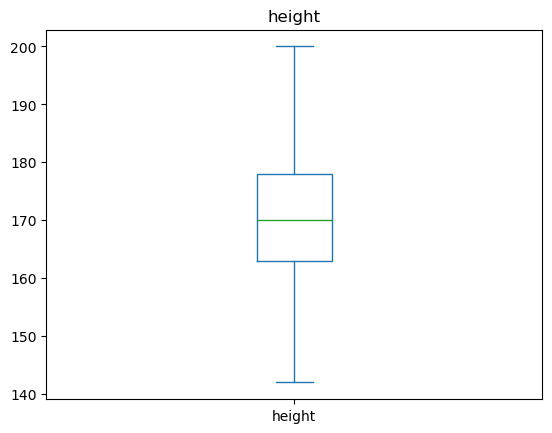

In [84]:
c_df["height"].plot(kind="box")
plt.title("height")
plt.show

### BMI

In [85]:
low_q1_bmi=Q1.BMI -1.5* IQR.BMI
low_q1_bmi

12.75

In [86]:
c_df=c_df.drop(c_df[c_df["BMI"] < low_q1_bmi].index)
c_df

,height,Weight,BMI,Alcohol_Consumption,Fruit_Consumption,Green_Vegetables_Consumption,FriedPotato_Consumption,Exercise_Yes,Heart_Disease_Yes,Skin_Cancer_Yes,Other_Cancer_Yes,Depression_Yes,Diabetes_Yes,Arthritis_Yes,Male,Smoking_History_Yes,General_Health,Age_Category
0,150,32.66,14.54,0,30,16,12,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,10.0
1,165,77.11,28.29,0,30,0,4,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,3.0,10.0
2,163,88.45,33.47,4,12,3,16,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,3.0,8.0
3,180,93.44,28.73,0,30,30,8,1.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,11.0
4,191,88.45,24.37,0,8,4,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,2.0,12.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
308769,168,81.65,29.05,4,30,8,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,3.0,1.0
308770,180,69.85,21.48,8,15,60,4,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,9.0
308771,157,61.23,24.69,4,40,8,4,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,3.0,2.0
308772,183,79.38,23.73,3,30,12,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,3.0,9.0


In [87]:
high_q3_bmi=Q3.BMI +1.5 *IQR.BMI
high_q3_bmi

43.31

In [88]:
c_df=c_df.drop(c_df[c_df["BMI"] > high_q3_bmi].index)
c_df

,height,Weight,BMI,Alcohol_Consumption,Fruit_Consumption,Green_Vegetables_Consumption,FriedPotato_Consumption,Exercise_Yes,Heart_Disease_Yes,Skin_Cancer_Yes,Other_Cancer_Yes,Depression_Yes,Diabetes_Yes,Arthritis_Yes,Male,Smoking_History_Yes,General_Health,Age_Category
0,150,32.66,14.54,0,30,16,12,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,10.0
1,165,77.11,28.29,0,30,0,4,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,3.0,10.0
2,163,88.45,33.47,4,12,3,16,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,3.0,8.0
3,180,93.44,28.73,0,30,30,8,1.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,11.0
4,191,88.45,24.37,0,8,4,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,2.0,12.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
308769,168,81.65,29.05,4,30,8,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,3.0,1.0
308770,180,69.85,21.48,8,15,60,4,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,9.0
308771,157,61.23,24.69,4,40,8,4,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,3.0,2.0
308772,183,79.38,23.73,3,30,12,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,3.0,9.0


In [89]:
c_df.reset_index(drop=True)

,height,Weight,BMI,Alcohol_Consumption,Fruit_Consumption,Green_Vegetables_Consumption,FriedPotato_Consumption,Exercise_Yes,Heart_Disease_Yes,Skin_Cancer_Yes,Other_Cancer_Yes,Depression_Yes,Diabetes_Yes,Arthritis_Yes,Male,Smoking_History_Yes,General_Health,Age_Category
0,150,32.66,14.54,0,30,16,12,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,10.0
1,165,77.11,28.29,0,30,0,4,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,3.0,10.0
2,163,88.45,33.47,4,12,3,16,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,3.0,8.0
3,180,93.44,28.73,0,30,30,8,1.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,11.0
4,191,88.45,24.37,0,8,4,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,2.0,12.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
295845,168,81.65,29.05,4,30,8,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,3.0,1.0
295846,180,69.85,21.48,8,15,60,4,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,9.0
295847,157,61.23,24.69,4,40,8,4,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,3.0,2.0
295848,183,79.38,23.73,3,30,12,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,3.0,9.0


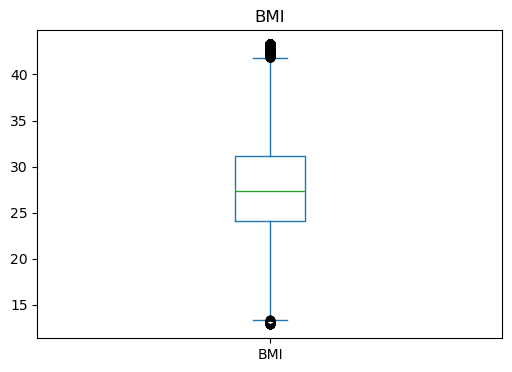

In [90]:
c_df["BMI"].plot(kind="box",figsize=(6,4))
plt.title("BMI")
plt.show()

* green vegetables consumption 

In [91]:
high_q3_veg=Q3.Green_Vegetables_Consumption +1.5 *IQR.Green_Vegetables_Consumption
high_q3_veg

44.0

In [92]:
c_df=c_df.drop(c_df[c_df["Green_Vegetables_Consumption"] > high_q3_veg].index)
c_df

,height,Weight,BMI,Alcohol_Consumption,Fruit_Consumption,Green_Vegetables_Consumption,FriedPotato_Consumption,Exercise_Yes,Heart_Disease_Yes,Skin_Cancer_Yes,Other_Cancer_Yes,Depression_Yes,Diabetes_Yes,Arthritis_Yes,Male,Smoking_History_Yes,General_Health,Age_Category
0,150,32.66,14.54,0,30,16,12,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,10.0
1,165,77.11,28.29,0,30,0,4,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,3.0,10.0
2,163,88.45,33.47,4,12,3,16,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,3.0,8.0
3,180,93.44,28.73,0,30,30,8,1.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,11.0
4,191,88.45,24.37,0,8,4,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,2.0,12.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
308768,168,58.97,20.98,0,16,12,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,2.0,7.0
308769,168,81.65,29.05,4,30,8,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,3.0,1.0
308771,157,61.23,24.69,4,40,8,4,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,3.0,2.0
308772,183,79.38,23.73,3,30,12,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,3.0,9.0


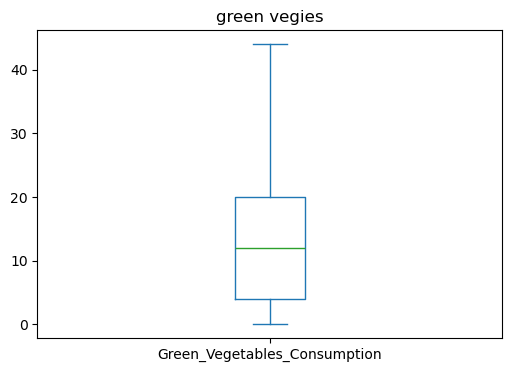

In [93]:
c_df["Green_Vegetables_Consumption"].plot(kind="box",figsize=(6,4))
plt.title("green vegies")
plt.show()

* fried potato consumption

In [94]:
high_q3_fried=Q3.FriedPotato_Consumption +1.5 *IQR.FriedPotato_Consumption
high_q3_fried


17.0

In [95]:
c_df=c_df.drop(c_df[c_df["FriedPotato_Consumption"] > high_q3_fried].index)
c_df

,height,Weight,BMI,Alcohol_Consumption,Fruit_Consumption,Green_Vegetables_Consumption,FriedPotato_Consumption,Exercise_Yes,Heart_Disease_Yes,Skin_Cancer_Yes,Other_Cancer_Yes,Depression_Yes,Diabetes_Yes,Arthritis_Yes,Male,Smoking_History_Yes,General_Health,Age_Category
0,150,32.66,14.54,0,30,16,12,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,10.0
1,165,77.11,28.29,0,30,0,4,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,3.0,10.0
2,163,88.45,33.47,4,12,3,16,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,3.0,8.0
3,180,93.44,28.73,0,30,30,8,1.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,11.0
4,191,88.45,24.37,0,8,4,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,2.0,12.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
308768,168,58.97,20.98,0,16,12,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,2.0,7.0
308769,168,81.65,29.05,4,30,8,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,3.0,1.0
308771,157,61.23,24.69,4,40,8,4,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,3.0,2.0
308772,183,79.38,23.73,3,30,12,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,3.0,9.0


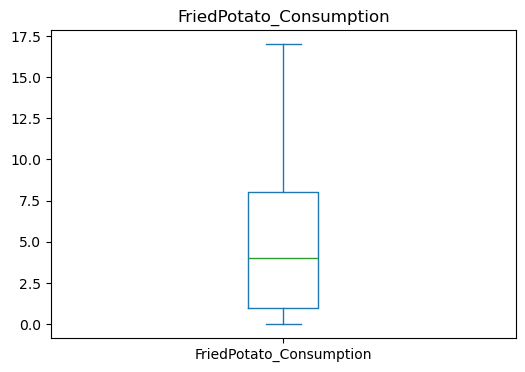

In [96]:
c_df["FriedPotato_Consumption"].plot(kind="box",figsize=(6,4))
plt.title("FriedPotato_Consumption")
plt.show()

In [97]:
c_df=c_df.reset_index(drop=True)
c_df

,height,Weight,BMI,Alcohol_Consumption,Fruit_Consumption,Green_Vegetables_Consumption,FriedPotato_Consumption,Exercise_Yes,Heart_Disease_Yes,Skin_Cancer_Yes,Other_Cancer_Yes,Depression_Yes,Diabetes_Yes,Arthritis_Yes,Male,Smoking_History_Yes,General_Health,Age_Category
0,150,32.66,14.54,0,30,16,12,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,10.0
1,165,77.11,28.29,0,30,0,4,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,3.0,10.0
2,163,88.45,33.47,4,12,3,16,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,3.0,8.0
3,180,93.44,28.73,0,30,30,8,1.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,11.0
4,191,88.45,24.37,0,8,4,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,2.0,12.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
267113,168,58.97,20.98,0,16,12,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,2.0,7.0
267114,168,81.65,29.05,4,30,8,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,3.0,1.0
267115,157,61.23,24.69,4,40,8,4,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,3.0,2.0
267116,183,79.38,23.73,3,30,12,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,3.0,9.0


* after removing the outliers of height, weight, BMI, green_vegetables_consumption, friedpotato_consumption the new shape of dateset is 267118 rows and 19 columns

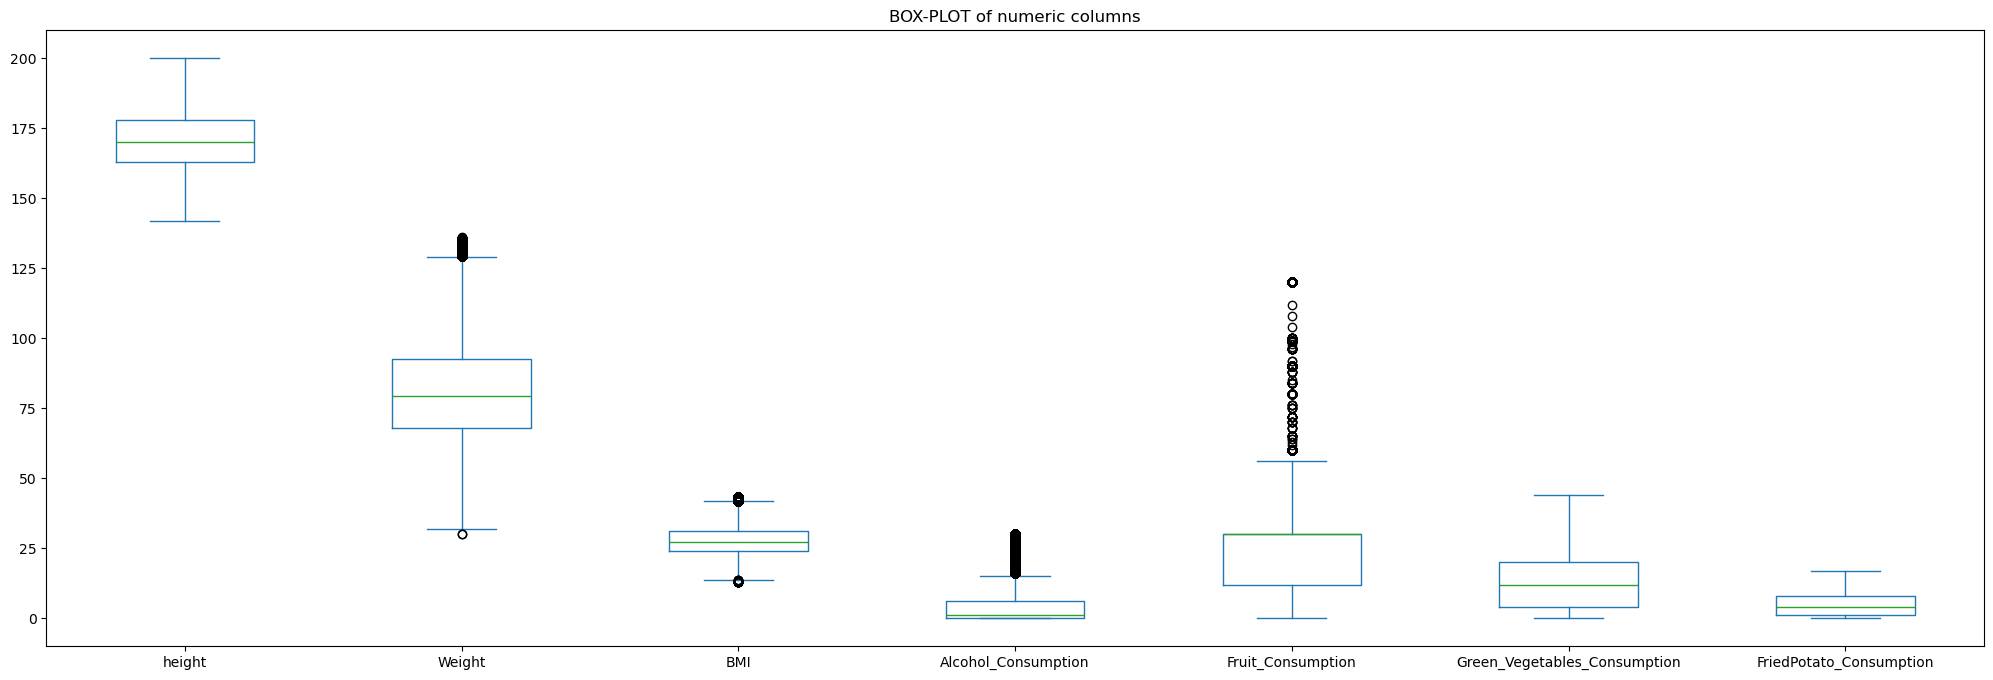

In [98]:
c_df[["height","Weight","BMI","Alcohol_Consumption",
      "Fruit_Consumption","Green_Vegetables_Consumption",
      "FriedPotato_Consumption"]].plot(kind="box",figsize=(25,8))
plt.title("BOX-PLOT of numeric columns")
plt.show()

In [99]:
c_df.describe()

,height,Weight,BMI,Alcohol_Consumption,Fruit_Consumption,Green_Vegetables_Consumption,FriedPotato_Consumption,Exercise_Yes,Heart_Disease_Yes,Skin_Cancer_Yes,Other_Cancer_Yes,Depression_Yes,Diabetes_Yes,Arthritis_Yes,Male,Smoking_History_Yes,General_Health,Age_Category
count,267118.000000,267118.000000,267118.000000,267118.000000,267118.000000,267118.000000,267118.000000,267118.000000,267118.000000,267118.000000,267118.000000,267118.000000,267118.000000,267118.000000,267118.000000,267118.000000,267118.000000,267118.000000
mean,170.451332,81.313194,27.895124,5.170442,29.444160,13.111299,4.684832,0.784054,0.080987,0.101289,0.099009,0.193570,0.131882,0.325849,0.475183,0.402249,2.558734,6.654467
std,10.323878,17.954383,5.248770,8.241390,24.331267,9.993565,4.187560,0.411478,0.272815,0.301711,0.298674,0.395096,0.338363,0.468692,0.499385,0.490353,1.017607,3.522532
min,142.000000,29.940000,12.870000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,163.000000,68.040000,24.130000,0.000000,12.000000,4.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,4.000000
50%,170.000000,79.380000,27.340000,1.000000,30.000000,12.000000,4.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000,7.000000
75%,178.000000,92.530000,31.180000,6.000000,30.000000,20.000000,8.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,3.000000,10.000000
max,200.000000,136.000000,43.280000,30.000000,120.000000,44.000000,17.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,4.000000,12.000000


* Alocohal consumption

In [100]:
high_q3_alcohol=Q3.Alcohol_Consumption +1.5 *IQR.Alcohol_Consumption
high_q3_alcohol

15.0

In [101]:
alcohol_outliers_count= (c_df["Alcohol_Consumption"] >high_q3_alcohol).sum()
print(alcohol_outliers_count)

31805


In [102]:
c_df["log_alcohol"]=np.log(c_df["Alcohol_Consumption"]+1)
c_df

,height,Weight,BMI,Alcohol_Consumption,Fruit_Consumption,Green_Vegetables_Consumption,FriedPotato_Consumption,Exercise_Yes,Heart_Disease_Yes,Skin_Cancer_Yes,Other_Cancer_Yes,Depression_Yes,Diabetes_Yes,Arthritis_Yes,Male,Smoking_History_Yes,General_Health,Age_Category,log_alcohol
0,150,32.66,14.54,0,30,16,12,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,10.0,0.000000
1,165,77.11,28.29,0,30,0,4,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,3.0,10.0,0.000000
2,163,88.45,33.47,4,12,3,16,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,3.0,8.0,1.609438
3,180,93.44,28.73,0,30,30,8,1.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,11.0,0.000000
4,191,88.45,24.37,0,8,4,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,2.0,12.0,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
267113,168,58.97,20.98,0,16,12,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,2.0,7.0,0.000000
267114,168,81.65,29.05,4,30,8,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,3.0,1.0,1.609438
267115,157,61.23,24.69,4,40,8,4,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,3.0,2.0,1.609438
267116,183,79.38,23.73,3,30,12,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,3.0,9.0,1.386294


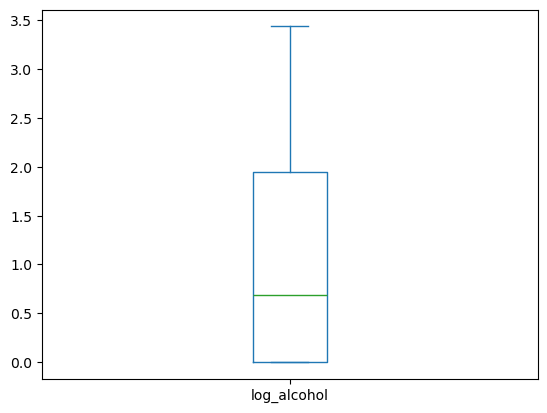

In [103]:
c_df["log_alcohol"].plot(kind="box")
plt.show()

* fruit consumption

In [104]:
high_q3_fruit=Q3.Fruit_Consumption +1.5 *IQR.Fruit_Consumption
high_q3_fruit

57.0

In [105]:
fruit_outliers_count=(c_df["Fruit_Consumption"]> high_q3_fruit).sum()
fruit_outliers_count

57182

In [106]:
c_df["log_fruit"]=np.log(c_df["Fruit_Consumption"]+1)
c_df

,height,Weight,BMI,Alcohol_Consumption,Fruit_Consumption,Green_Vegetables_Consumption,FriedPotato_Consumption,Exercise_Yes,Heart_Disease_Yes,Skin_Cancer_Yes,Other_Cancer_Yes,Depression_Yes,Diabetes_Yes,Arthritis_Yes,Male,Smoking_History_Yes,General_Health,Age_Category,log_alcohol,log_fruit
0,150,32.66,14.54,0,30,16,12,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,10.0,0.000000,3.433987
1,165,77.11,28.29,0,30,0,4,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,3.0,10.0,0.000000,3.433987
2,163,88.45,33.47,4,12,3,16,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,3.0,8.0,1.609438,2.564949
3,180,93.44,28.73,0,30,30,8,1.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,11.0,0.000000,3.433987
4,191,88.45,24.37,0,8,4,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,2.0,12.0,0.000000,2.197225
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
267113,168,58.97,20.98,0,16,12,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,2.0,7.0,0.000000,2.833213
267114,168,81.65,29.05,4,30,8,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,3.0,1.0,1.609438,3.433987
267115,157,61.23,24.69,4,40,8,4,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,3.0,2.0,1.609438,3.713572
267116,183,79.38,23.73,3,30,12,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,3.0,9.0,1.386294,3.433987


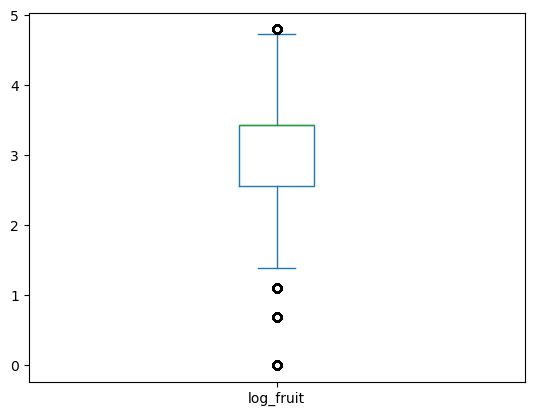

In [107]:
c_df["log_fruit"].plot(kind="box")
plt.show()

In [108]:
c_df=c_df.drop(columns=["Fruit_Consumption","Alcohol_Consumption"])
c_df

,height,Weight,BMI,Green_Vegetables_Consumption,FriedPotato_Consumption,Exercise_Yes,Heart_Disease_Yes,Skin_Cancer_Yes,Other_Cancer_Yes,Depression_Yes,Diabetes_Yes,Arthritis_Yes,Male,Smoking_History_Yes,General_Health,Age_Category,log_alcohol,log_fruit
0,150,32.66,14.54,16,12,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,10.0,0.000000,3.433987
1,165,77.11,28.29,0,4,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,3.0,10.0,0.000000,3.433987
2,163,88.45,33.47,3,16,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,3.0,8.0,1.609438,2.564949
3,180,93.44,28.73,30,8,1.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,11.0,0.000000,3.433987
4,191,88.45,24.37,4,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,2.0,12.0,0.000000,2.197225
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
267113,168,58.97,20.98,12,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,2.0,7.0,0.000000,2.833213
267114,168,81.65,29.05,8,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,3.0,1.0,1.609438,3.433987
267115,157,61.23,24.69,8,4,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,3.0,2.0,1.609438,3.713572
267116,183,79.38,23.73,12,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,3.0,9.0,1.386294,3.433987


# SATGE 6 Visualization

### Univariate plotting:


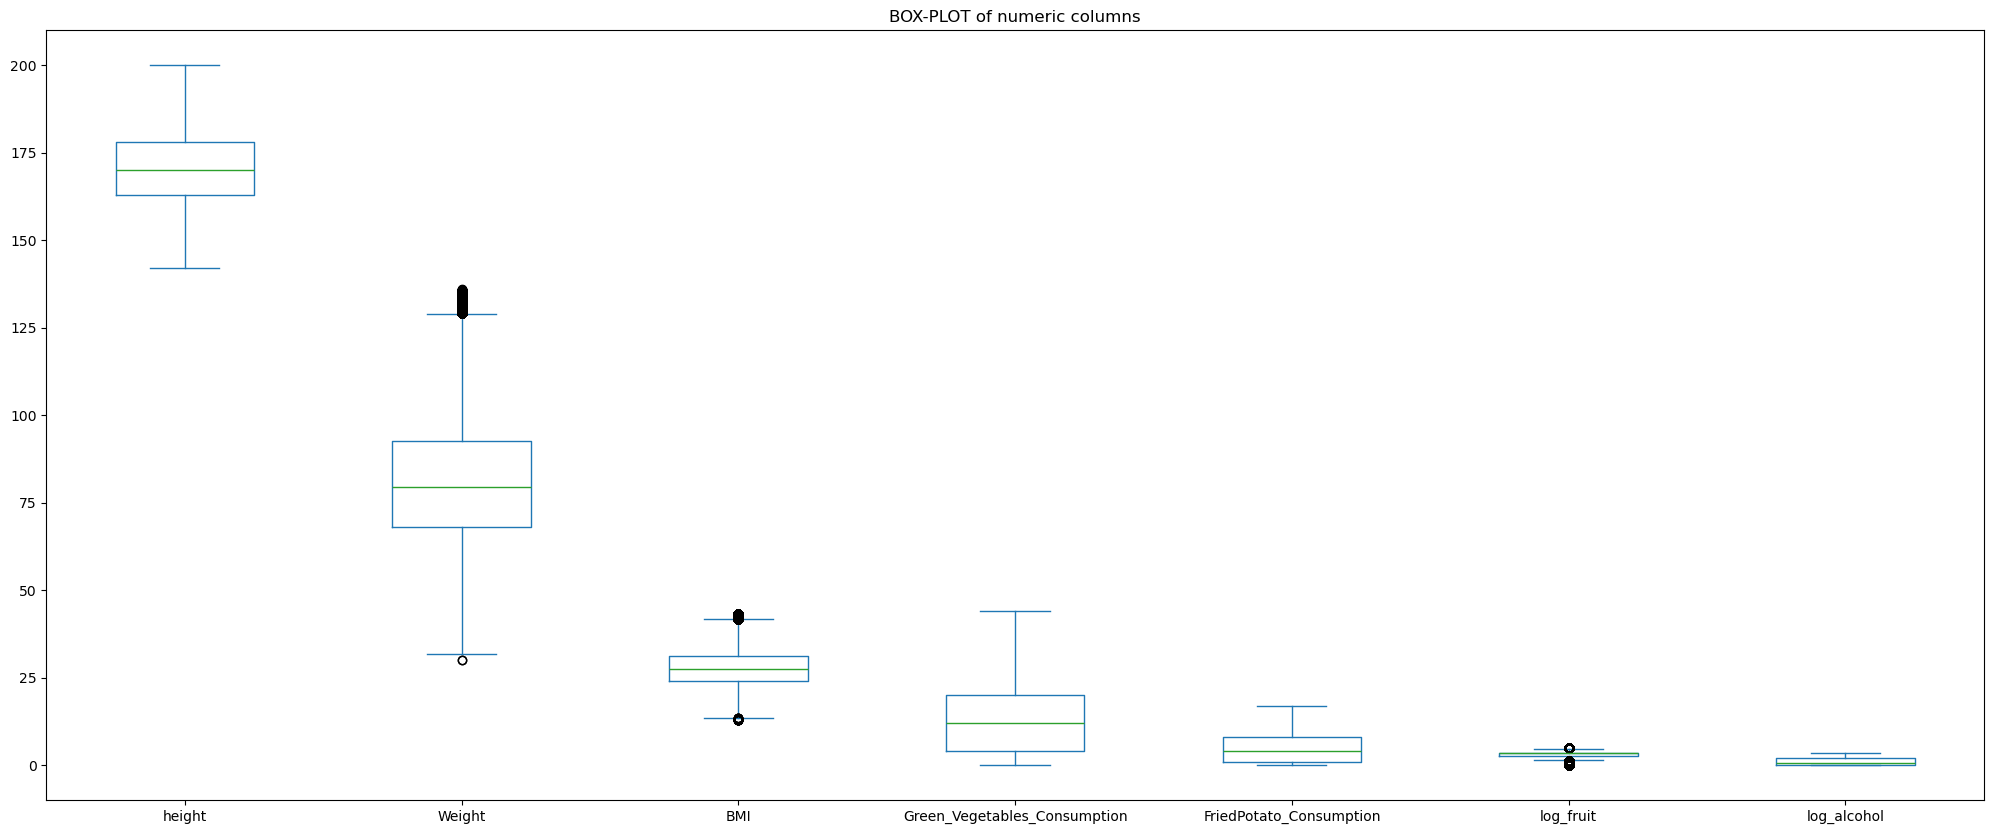

In [109]:
c_df[["height","Weight","BMI","Green_Vegetables_Consumption",
      "FriedPotato_Consumption","log_fruit","log_alcohol"]].plot(kind="box",figsize=(25,10))
plt.title("BOX-PLOT of numeric columns")
plt.show()

* using log transformation(base e) the column fruit_consumption and alcohol_consumption are balanced.
* they both are cover major portin of our dataset fruit_consumption have 57182 and alcohol_consumption have 31805 rows.
* at this point we removed and treat all necessary outliers.

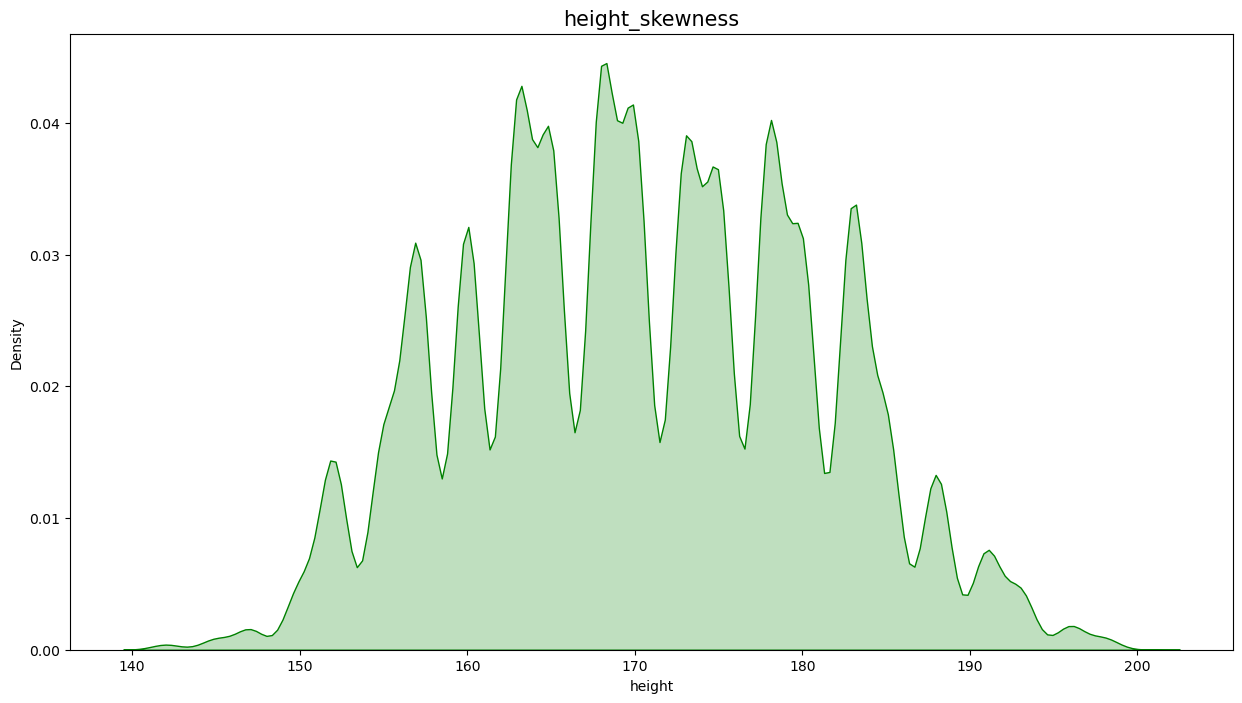

In [110]:
plt.figure(figsize=(15,8))
sns.kdeplot(c_df["height"], color="green", fill=True)
plt.title("height_skewness",size=15)
plt.show()

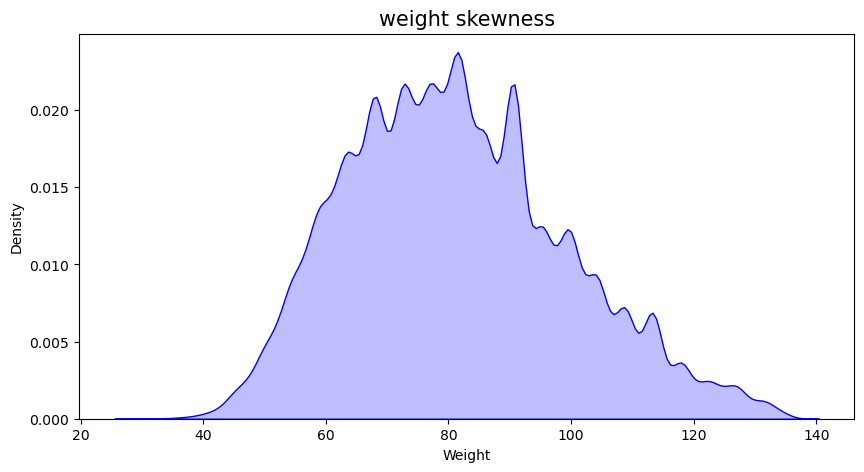

In [111]:
plt.figure(figsize=(10,5))
sns.kdeplot(c_df["Weight"], color="blue", fill=True)
plt.title("weight skewness",size=15)
plt.show()


* the skewness of column exercise_yes to diabetes_yes is not harmfull because they are binary columns.
  

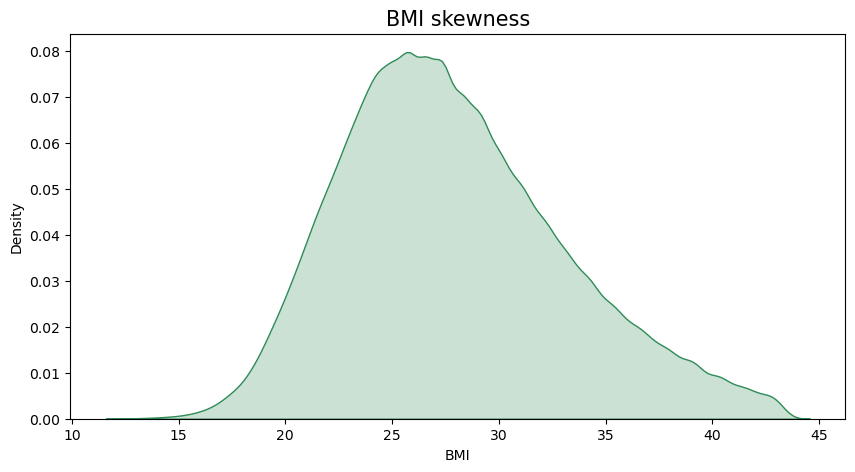

In [112]:
plt.figure(figsize=(10,5))
sns.kdeplot(c_df["BMI"], color="seagreen", fill=True)
plt.title("BMI skewness",size=15)
plt.show()


1. box-plot:
    * to find outliers

2. kde-plot:
    * to find the skewness through plots.

### Bivariate analysis

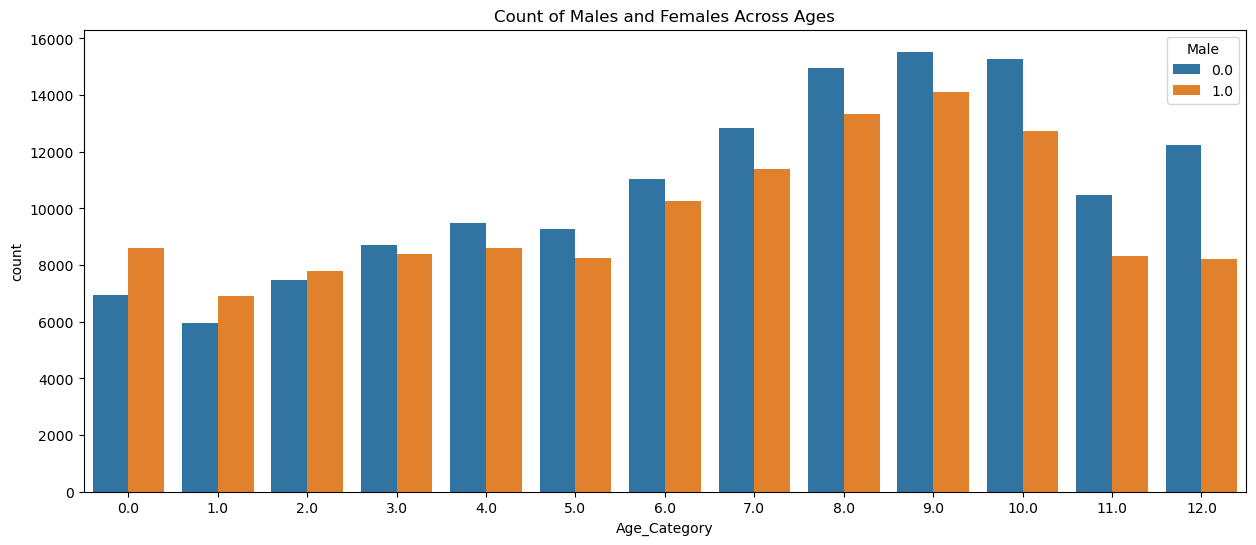

In [113]:
plt.figure(figsize=(15,6))
sns.countplot(x="Age_Category", hue="Male", data=c_df)
plt.title("Count of Males and Females Across Ages")
plt.show()

* from here, in all plots 0 means NO and 1 means YES.
* they are divied into 13 categories of age .

Text(0.5, 1.0, 'skin_canser in each age_category')

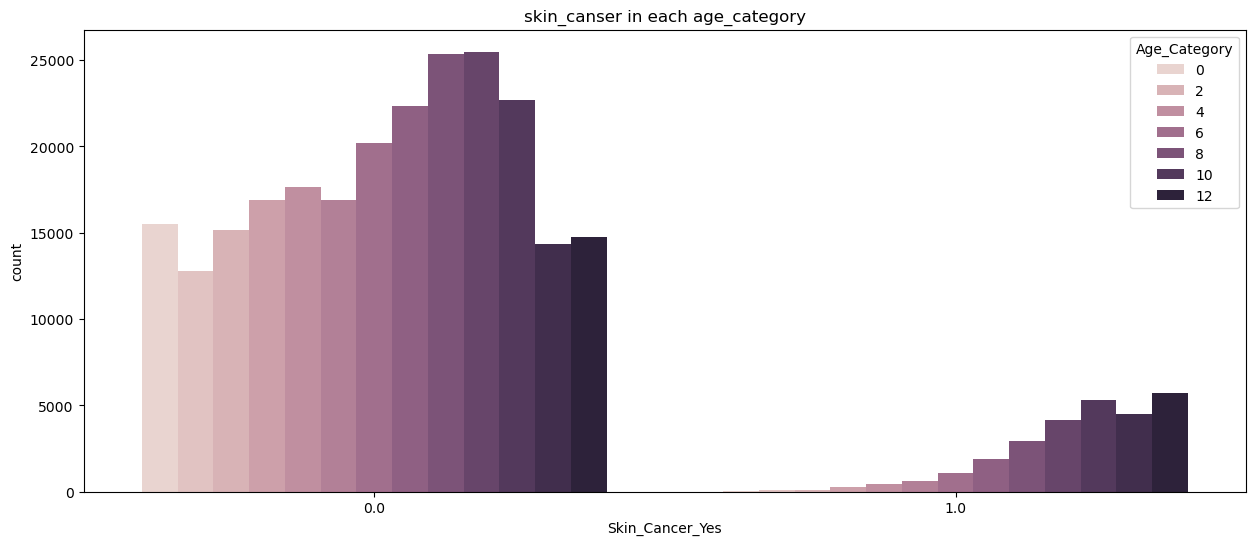

In [114]:
plt.figure(figsize=(15,6))
sns.countplot(c_df, x="Skin_Cancer_Yes",hue="Age_Category")
plt.title("skin_canser in each age_category")

* it shows skin cancer in different ages , mostly population have no skin cancer.
* mostly older peoples have skin cancer.

Text(0.5, 1.0, 'other_cancer in each age_category')

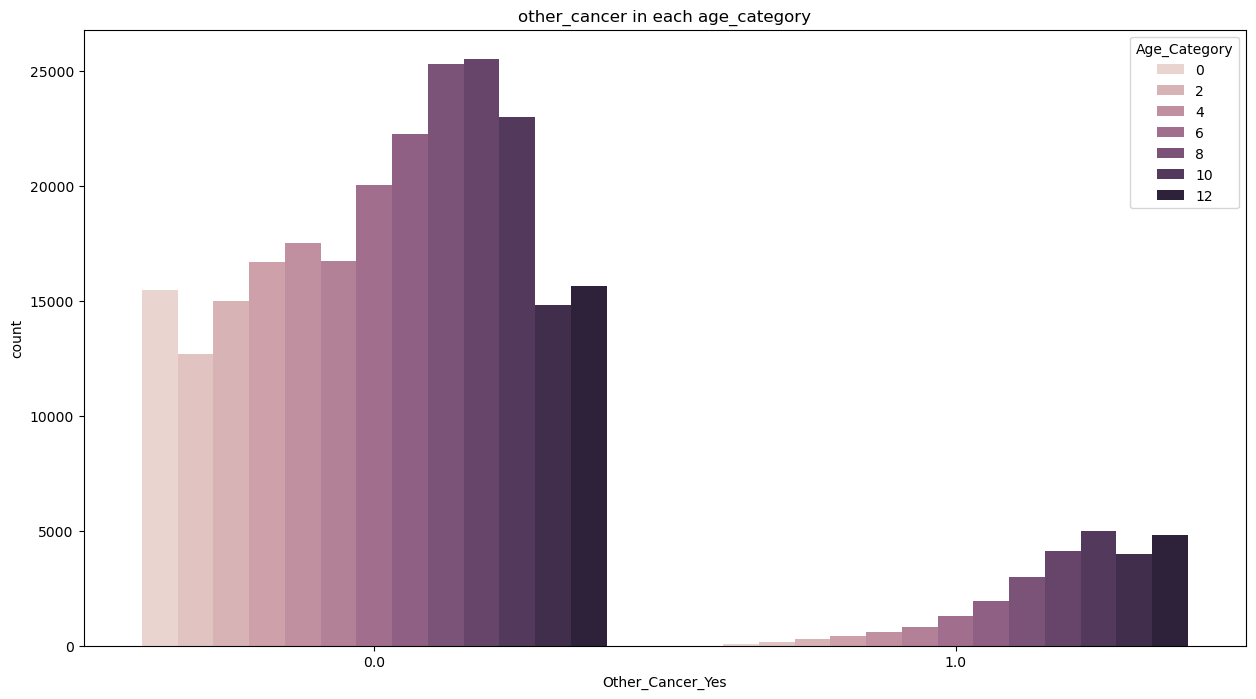

In [115]:
plt.figure(figsize=(15,8))
sns.countplot(c_df,x="Other_Cancer_Yes",hue="Age_Category")
plt.title("other_cancer in each age_category")

* this is also same as skin cancer.

Text(0.5, 1.0, 'Diabetes in each age_category')

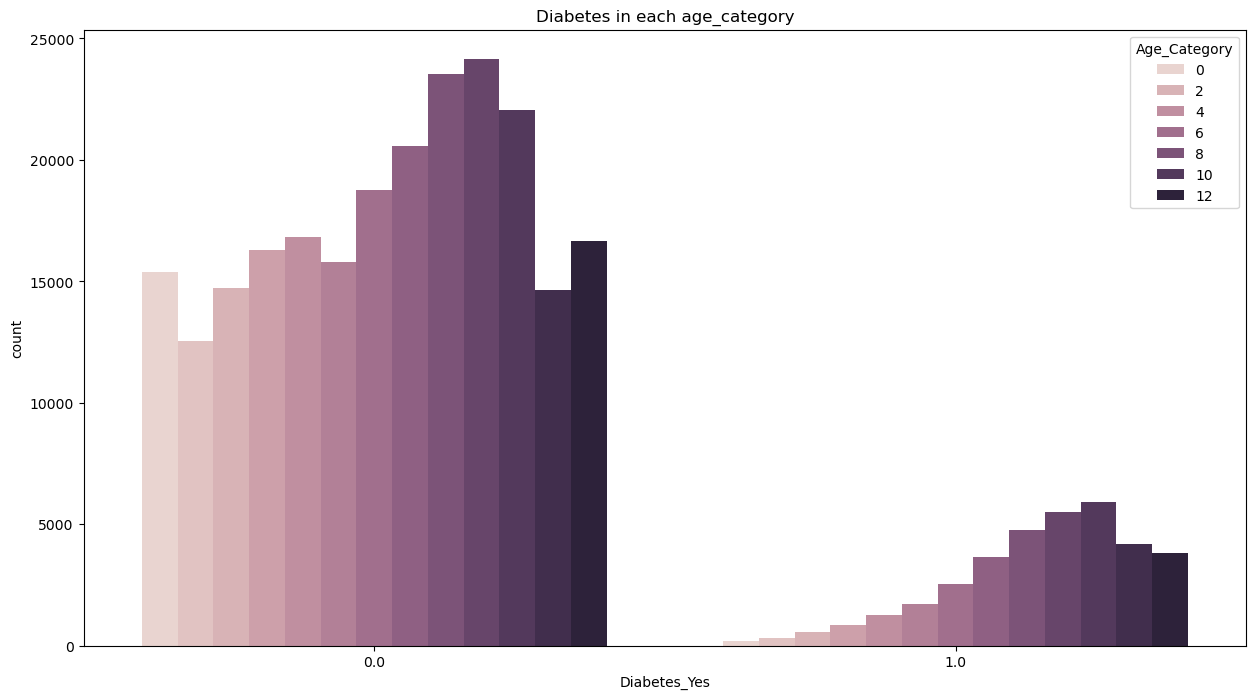

In [116]:
plt.figure(figsize=(15,8))
sns.countplot(c_df,x="Diabetes_Yes",hue="Age_Category")
plt.title("Diabetes in each age_category")

* it shows diabetic population , mostly diabitic lies in 10th age category.

### multivariate analysis


Text(0.5, 1.0, 'alcohol_consumption in each age_category')

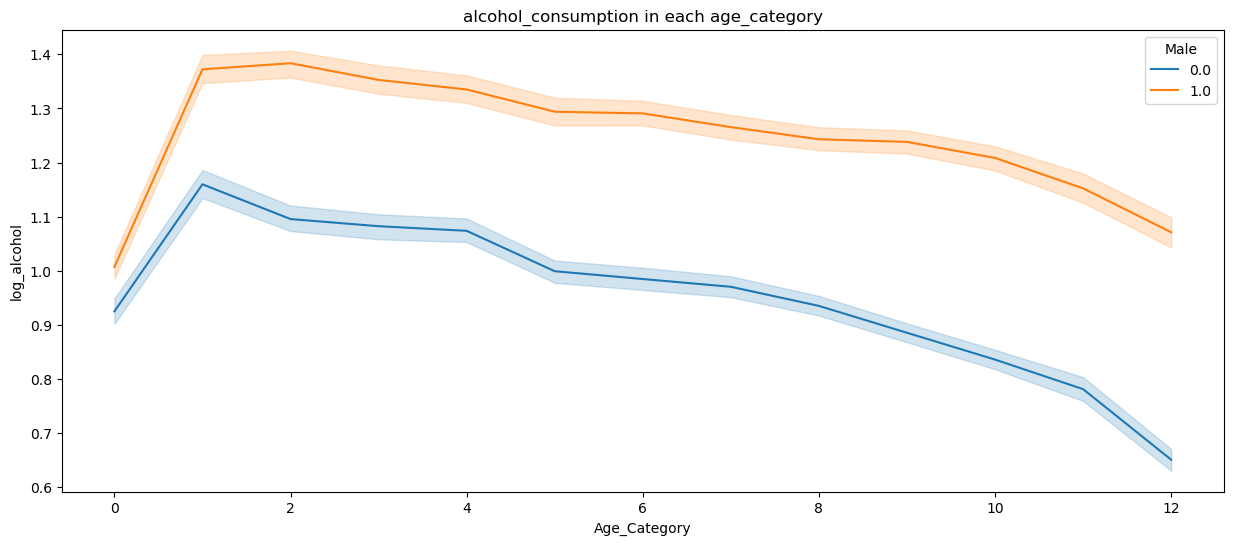

In [117]:
plt.figure(figsize=(15,6))
sns.lineplot(c_df,y="log_alcohol", x="Age_Category",hue="Male")
plt.title("alcohol_consumption in each age_category")

Text(0.5, 1.0, 'fruit_consumption in each age_category')

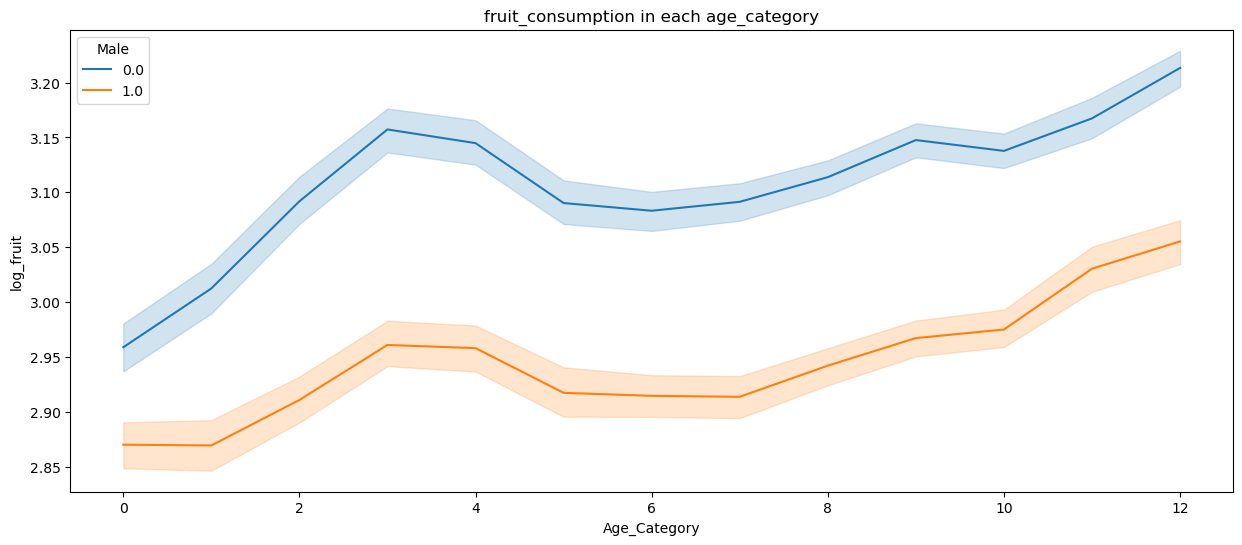

In [118]:
plt.figure(figsize=(15,6))
sns.lineplot(c_df,y="log_fruit", x="Age_Category",hue="Male")
plt.title("fruit_consumption in each age_category")

Text(0.5, 1.0, 'FriedPotato_Consumption in each age_category')

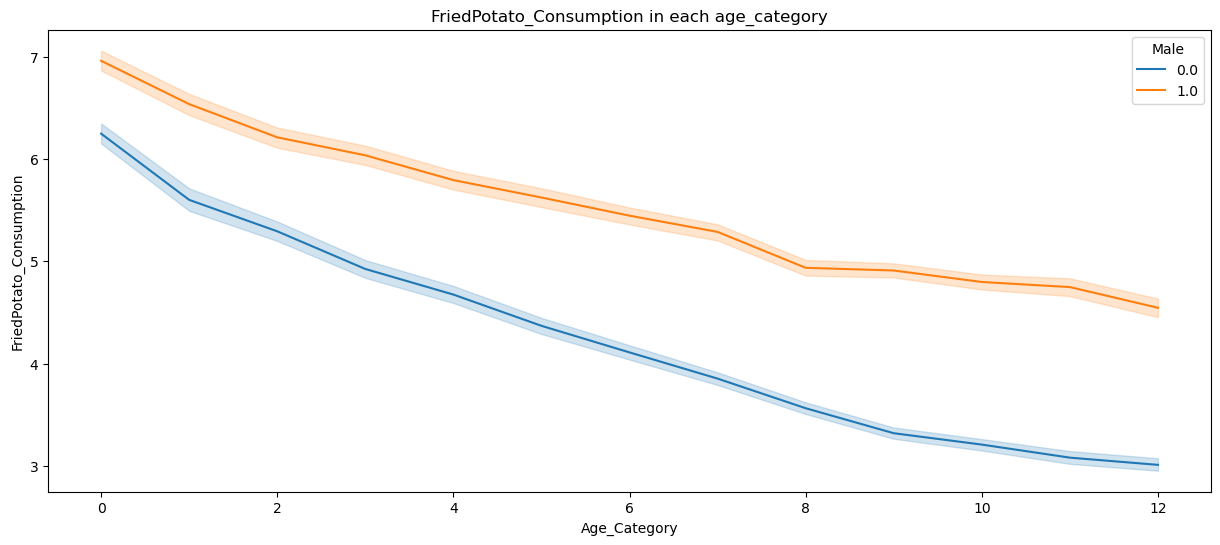

In [119]:
plt.figure(figsize=(15,6))
sns.lineplot(c_df,y="FriedPotato_Consumption", x="Age_Category",hue="Male")
plt.title("FriedPotato_Consumption in each age_category")

Text(0.5, 1.0, 'Green_Vegetables_consumption in each age_category')

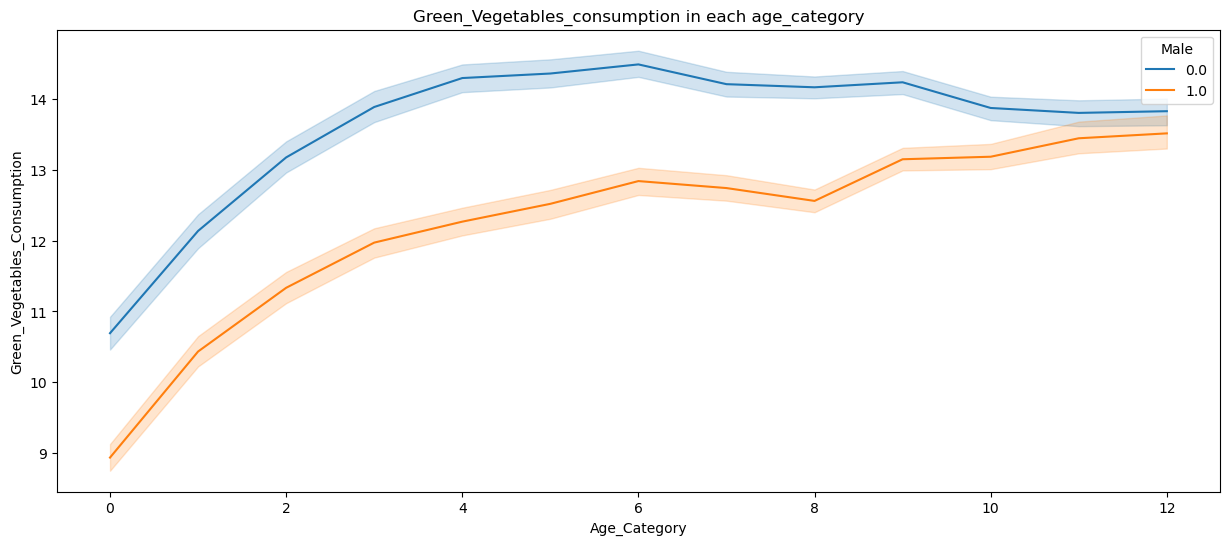

In [120]:
plt.figure(figsize=(15,6))
sns.lineplot(c_df,y="Green_Vegetables_Consumption", x="Age_Category",hue="Male")
plt.title("Green_Vegetables_consumption in each age_category")

<Axes: >

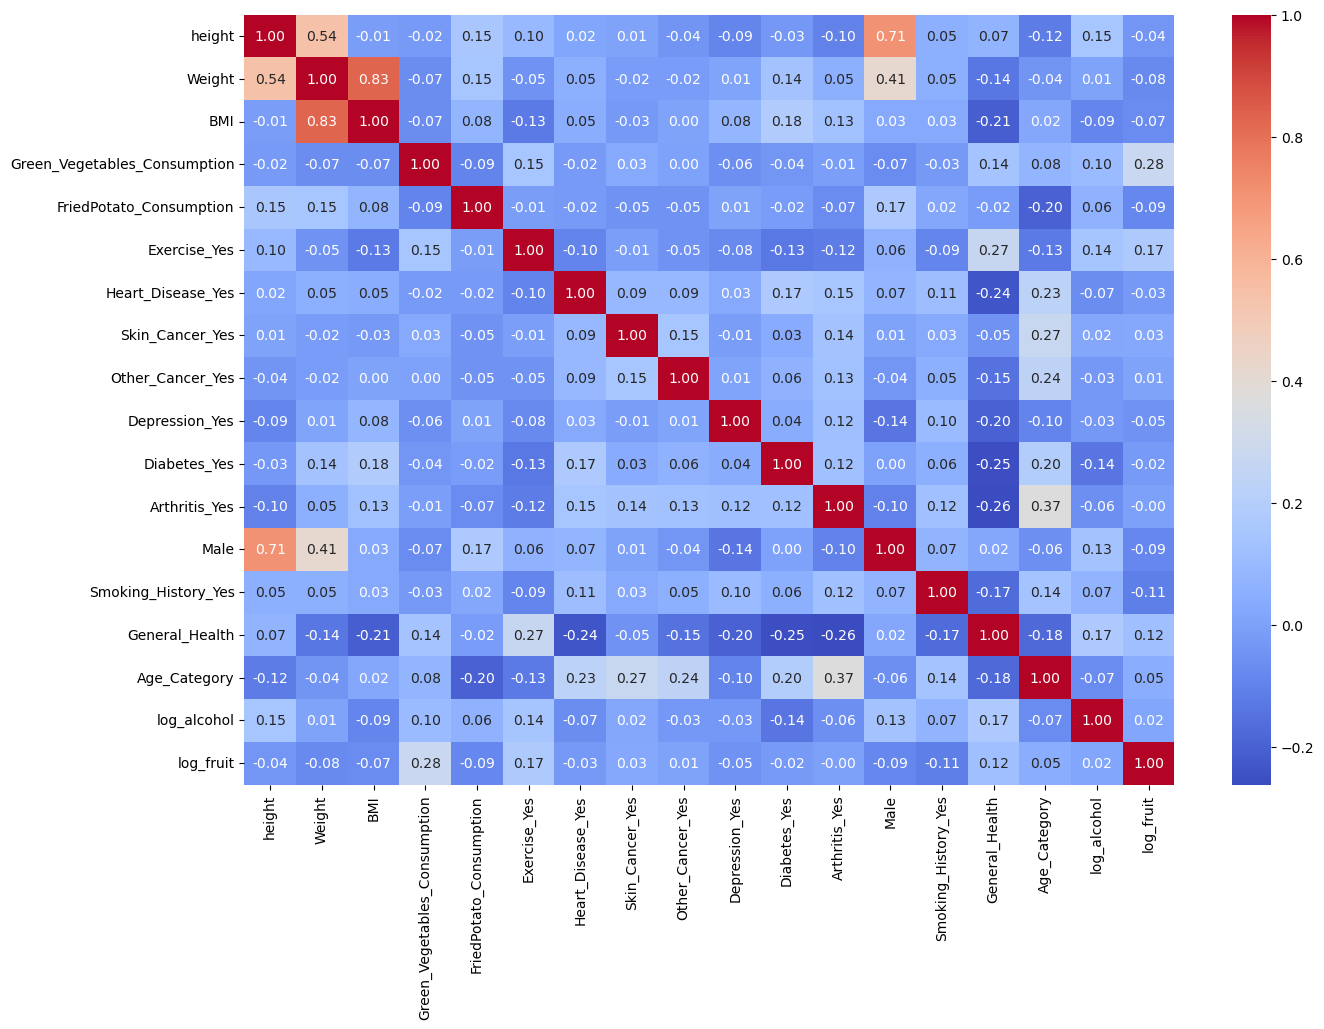

In [121]:
plt.figure(figsize=(15,10))
sns.heatmap(c_df.corr(), annot=True, fmt=".2f", cmap='coolwarm')


1. heatmap:
    * to find relationship between columns.
    * for checking multicolinearity.
* form the heat map:
  * there is high multicolinearity between height and BMI, hieght and Male.
  * and moderate multicolinearity between Weight and height.

2. line plot :
   * the 1st line plot shows alcohol consumption in each age category , it shows high usage of alcohol in 2nd age category both males and females.
   * the 2nd plot shows fruit consumption, it shows moderate fruit intake in each age category.
   * 3rd shows fried potato consumption, it shows down ward graph from age category 0 to 12 , 0 have highest consumption and 12 have lowest.
   * 4th shows green vegetables consumption, it shows up ward graph means as the age grows the vegetable consumption increases.

# STAGE 7 EDA 

In [122]:
c_df.describe()

,height,Weight,BMI,Green_Vegetables_Consumption,FriedPotato_Consumption,Exercise_Yes,Heart_Disease_Yes,Skin_Cancer_Yes,Other_Cancer_Yes,Depression_Yes,Diabetes_Yes,Arthritis_Yes,Male,Smoking_History_Yes,General_Health,Age_Category,log_alcohol,log_fruit
count,267118.000000,267118.000000,267118.000000,267118.000000,267118.000000,267118.000000,267118.000000,267118.000000,267118.000000,267118.000000,267118.000000,267118.000000,267118.000000,267118.000000,267118.000000,267118.000000,267118.000000,267118.000000
mean,170.451332,81.313194,27.895124,13.111299,4.684832,0.784054,0.080987,0.101289,0.099009,0.193570,0.131882,0.325849,0.475183,0.402249,2.558734,6.654467,1.079356,3.036710
std,10.323878,17.954383,5.248770,9.993565,4.187560,0.411478,0.272815,0.301711,0.298674,0.395096,0.338363,0.468692,0.499385,0.490353,1.017607,3.522532,1.173932,0.988459
min,142.000000,29.940000,12.870000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,163.000000,68.040000,24.130000,4.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,4.000000,0.000000,2.564949
50%,170.000000,79.380000,27.340000,12.000000,4.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000,7.000000,0.693147,3.433987
75%,178.000000,92.530000,31.180000,20.000000,8.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,3.000000,10.000000,1.945910,3.433987
max,200.000000,136.000000,43.280000,44.000000,17.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,4.000000,12.000000,3.433987,4.795791


In [123]:
c_df.std()

height                          10.323878
Weight                          17.954383
BMI                              5.248770
Green_Vegetables_Consumption     9.993565
FriedPotato_Consumption          4.187560
Exercise_Yes                     0.411478
Heart_Disease_Yes                0.272815
Skin_Cancer_Yes                  0.301711
Other_Cancer_Yes                 0.298674
Depression_Yes                   0.395096
Diabetes_Yes                     0.338363
Arthritis_Yes                    0.468692
Male                             0.499385
Smoking_History_Yes              0.490353
General_Health                   1.017607
Age_Category                     3.522532
log_alcohol                      1.173932
log_fruit                        0.988459
dtype: float64

* according to standard_deviation : height, weight, green_vegetables_consumption have slightly high means data points are spread out over a wide range.

In [124]:
c_df.skew()

height                          0.066028
Weight                          0.393513
BMI                             0.487870
Green_Vegetables_Consumption    0.585948
FriedPotato_Consumption         1.009947
Exercise_Yes                   -1.380665
Heart_Disease_Yes               3.071797
Skin_Cancer_Yes                 2.643022
Other_Cancer_Yes                2.685162
Depression_Yes                  1.551178
Diabetes_Yes                    2.175895
Arthritis_Yes                   0.743144
Male                            0.099390
Smoking_History_Yes             0.398699
General_Health                 -0.428489
Age_Category                   -0.302941
log_alcohol                     0.627716
log_fruit                      -0.875840
dtype: float64

### standard scaler and VIF

In [125]:
c_df=c_df.drop(columns=["Weight","height"])
c_df

,BMI,Green_Vegetables_Consumption,FriedPotato_Consumption,Exercise_Yes,Heart_Disease_Yes,Skin_Cancer_Yes,Other_Cancer_Yes,Depression_Yes,Diabetes_Yes,Arthritis_Yes,Male,Smoking_History_Yes,General_Health,Age_Category,log_alcohol,log_fruit
0,14.54,16,12,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,10.0,0.000000,3.433987
1,28.29,0,4,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,3.0,10.0,0.000000,3.433987
2,33.47,3,16,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,3.0,8.0,1.609438,2.564949
3,28.73,30,8,1.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,11.0,0.000000,3.433987
4,24.37,4,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,2.0,12.0,0.000000,2.197225
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
267113,20.98,12,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,2.0,7.0,0.000000,2.833213
267114,29.05,8,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,3.0,1.0,1.609438,3.433987
267115,24.69,8,4,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,3.0,2.0,1.609438,3.713572
267116,23.73,12,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,3.0,9.0,1.386294,3.433987


In [126]:
x=c_df.drop("Heart_Disease_Yes",axis=1)
x

,BMI,Green_Vegetables_Consumption,FriedPotato_Consumption,Exercise_Yes,Skin_Cancer_Yes,Other_Cancer_Yes,Depression_Yes,Diabetes_Yes,Arthritis_Yes,Male,Smoking_History_Yes,General_Health,Age_Category,log_alcohol,log_fruit
0,14.54,16,12,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,10.0,0.000000,3.433987
1,28.29,0,4,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,3.0,10.0,0.000000,3.433987
2,33.47,3,16,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,3.0,8.0,1.609438,2.564949
3,28.73,30,8,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,11.0,0.000000,3.433987
4,24.37,4,0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,2.0,12.0,0.000000,2.197225
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
267113,20.98,12,0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,2.0,7.0,0.000000,2.833213
267114,29.05,8,0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,3.0,1.0,1.609438,3.433987
267115,24.69,8,4,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,3.0,2.0,1.609438,3.713572
267116,23.73,12,0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,3.0,9.0,1.386294,3.433987


In [127]:
y=pd.DataFrame(c_df["Heart_Disease_Yes"])
y

,Heart_Disease_Yes
0,0.0
1,1.0
2,0.0
3,1.0
4,0.0
...,...
267113,0.0
267114,0.0
267115,0.0
267116,0.0


In [128]:
std_sclr=StandardScaler()

In [129]:
x_scaled=std_sclr.fit_transform(x)
x_scaled

array([[-2.54443425,  0.28905664,  1.7468841 , ...,  0.94975397,
        -0.91943792,  0.40191616],
       [ 0.07523224, -1.31197662, -0.16353998, ...,  0.94975397,
        -0.91943792,  0.40191616],
       [ 1.06213205, -1.01178289,  2.70209614, ...,  0.38197953,
         0.45154469, -0.47727021],
       ...,
       [-0.61064408, -0.51145999, -0.16353998, ..., -1.32134378,
         0.45154469,  0.68476598],
       [-0.79354443, -0.11120168, -1.11875203, ...,  0.66586675,
         0.26146222,  0.40191616],
       [ 0.72681474, -0.11120168, -0.87994902, ..., -0.46968212,
        -0.32898785, -1.25948932]])

* this task is done to perform accurate vif.
* because of scaling all columns on same scale.

In [130]:
#initialization of dataframe vif data
vif=pd.DataFrame()

In [131]:
vif["vif_values"]=[variance_inflation_factor(x_scaled,i) for i in range(x_scaled.shape[1])]

In [132]:
# the upper cell collect the vif values and
# this cell collects the name of features
vif["features"]=x.columns

* before removing weight and height
---
| VIF Value  | Feature                      |
|------------|------------------------------|
| 30.745218  | height                       |
| 97.109708  | Weight                       |
| 69.190085  | BMI                          |
| 1.130516   | Green_Vegetables_Consumption |
| 1.088632   | FriedPotato_Consumption      |
| 1.149433   | Exercise_Yes                 |
| 1.097771   | Skin_Cancer_Yes              |
| 1.083700   | Other_Cancer_Yes             |
| 1.113894   | Depression_Yes               |
| 1.132414   | Diabetes_Yes                 |
| 1.258916   | Arthritis_Yes                |
| 2.086223   | Male                         |
| 1.085635   | Smoking_History_Yes          |
| 1.318644   | General_Health               |
| 1.446190   | Age_Category                 |
| 1.096046   | log_alcohol                  |
| 1.131296   | log_fruit                    |


In [133]:
vif

,vif_values,features
0,1.094835,BMI
1,1.129609,Green_Vegetables_Consumption
2,1.087160,FriedPotato_Consumption
3,1.147524,Exercise_Yes
4,1.096972,Skin_Cancer_Yes
5,1.083435,Other_Cancer_Yes
6,1.113056,Depression_Yes
7,1.132232,Diabetes_Yes
8,1.258758,Arthritis_Yes
9,1.099674,Male


* after removing the height and weight the VIF looks like this.

### Sampling

In [134]:
c_df["Heart_Disease_Yes"].value_counts()

Heart_Disease_Yes
0.0    245485
1.0     21633
Name: count, dtype: int64

In [135]:
X = c_df.drop('Heart_Disease_Yes', axis=1)
Y = c_df['Heart_Disease_Yes']  # Treat gender as the target class

ros = RandomOverSampler()
X_resampled, Y_resampled = ros.fit_resample(X, Y)
print(X_resampled,Y_resampled)

          BMI  Green_Vegetables_Consumption  FriedPotato_Consumption  \
0       14.54                            16                       12   
1       28.29                             0                        4   
2       33.47                             3                       16   
3       28.73                            30                        8   
4       24.37                             4                        0   
...       ...                           ...                      ...   
490965  28.06                            20                        0   
490966  24.63                             4                        1   
490967  23.40                             4                        4   
490968  34.16                            30                        8   
490969  41.60                             8                        0   

        Exercise_Yes  Skin_Cancer_Yes  Other_Cancer_Yes  Depression_Yes  \
0                0.0              0.0               0.0     

In [136]:
sample_df=pd.DataFrame(X_resampled)
sample_df["Heart_Disease_Yes"]=Y_resampled
sample_df

,BMI,Green_Vegetables_Consumption,FriedPotato_Consumption,Exercise_Yes,Skin_Cancer_Yes,Other_Cancer_Yes,Depression_Yes,Diabetes_Yes,Arthritis_Yes,Male,Smoking_History_Yes,General_Health,Age_Category,log_alcohol,log_fruit,Heart_Disease_Yes
0,14.54,16,12,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,10.0,0.000000,3.433987,0.0
1,28.29,0,4,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,3.0,10.0,0.000000,3.433987,1.0
2,33.47,3,16,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,3.0,8.0,1.609438,2.564949,0.0
3,28.73,30,8,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,11.0,0.000000,3.433987,1.0
4,24.37,4,0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,2.0,12.0,0.000000,2.197225,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
490965,28.06,20,0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,3.0,12.0,0.000000,1.609438,1.0
490966,24.63,4,1,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,1.0,3.0,0.000000,1.098612,1.0
490967,23.40,4,4,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,3.0,12.0,0.000000,3.433987,1.0
490968,34.16,30,8,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,3.0,10.0,0.693147,3.433987,1.0


In [137]:
sample_df["Heart_Disease_Yes"].value_counts()

Heart_Disease_Yes
0.0    245485
1.0    245485
Name: count, dtype: int64

<Axes: >

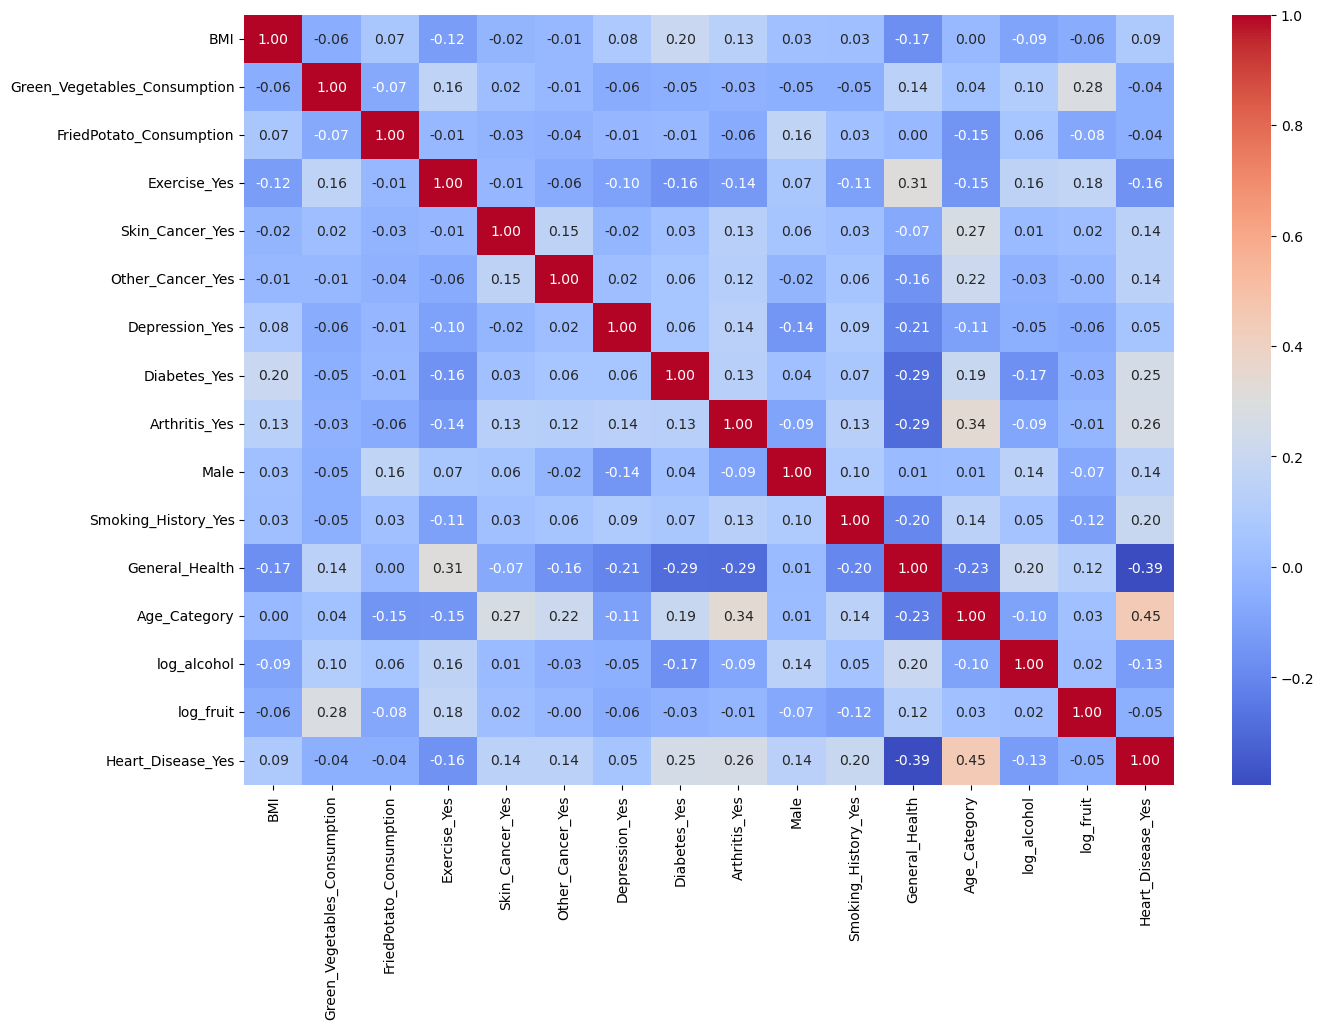

In [138]:
plt.figure(figsize=(15,10))
sns.heatmap(sample_df.corr(), annot=True, fmt=".2f", cmap="coolwarm")

In [139]:
sample_df.skew()

BMI                             0.417562
Green_Vegetables_Consumption    0.627000
FriedPotato_Consumption         1.038431
Exercise_Yes                   -0.994737
Skin_Cancer_Yes                 2.038554
Other_Cancer_Yes                2.062729
Depression_Yes                  1.409991
Diabetes_Yes                    1.363197
Arthritis_Yes                   0.262769
Male                           -0.128616
Smoking_History_Yes             0.061573
General_Health                 -0.207428
Age_Category                   -0.744695
log_alcohol                     0.840529
log_fruit                      -0.845560
Heart_Disease_Yes               0.000000
dtype: float64

* we plot heatmap and check skewness for sample_df which is oversampled, to check all thing are work well.

In [140]:
sam_features=sample_df.drop("Heart_Disease_Yes",axis=1)
sam_features

,BMI,Green_Vegetables_Consumption,FriedPotato_Consumption,Exercise_Yes,Skin_Cancer_Yes,Other_Cancer_Yes,Depression_Yes,Diabetes_Yes,Arthritis_Yes,Male,Smoking_History_Yes,General_Health,Age_Category,log_alcohol,log_fruit
0,14.54,16,12,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,10.0,0.000000,3.433987
1,28.29,0,4,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,3.0,10.0,0.000000,3.433987
2,33.47,3,16,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,3.0,8.0,1.609438,2.564949
3,28.73,30,8,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,11.0,0.000000,3.433987
4,24.37,4,0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,2.0,12.0,0.000000,2.197225
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
490965,28.06,20,0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,3.0,12.0,0.000000,1.609438
490966,24.63,4,1,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,1.0,3.0,0.000000,1.098612
490967,23.40,4,4,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,3.0,12.0,0.000000,3.433987
490968,34.16,30,8,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,3.0,10.0,0.693147,3.433987


In [141]:
sam_target=sample_df["Heart_Disease_Yes"]
sam_target

0         0.0
1         1.0
2         0.0
3         1.0
4         0.0
         ... 
490965    1.0
490966    1.0
490967    1.0
490968    1.0
490969    1.0
Name: Heart_Disease_Yes, Length: 490970, dtype: float64

In [142]:
sam_x_scaled=std_sclr.fit_transform(sam_features)
sam_x_scaled

array([[-2.61621957e+00,  3.21929233e-01,  1.78458236e+00, ...,
         6.34952624e-01, -8.18140603e-01,  4.34181950e-01],
       [ 2.52606226e-03, -1.27384347e+00, -1.29643612e-01, ...,
         6.34952624e-01, -8.18140603e-01,  4.34181950e-01],
       [ 9.89078961e-01, -9.74636084e-01,  2.74169534e+00, ...,
         3.19354561e-02,  5.58947843e-01, -4.29156364e-01],
       ...,
       [-9.28795111e-01, -8.74900291e-01, -1.29643612e-01, ...,
         1.23796979e+00, -8.18140603e-01,  4.34181950e-01],
       [ 1.12049238e+00,  1.71823034e+00,  8.27469373e-01, ...,
         6.34952624e-01, -2.25060891e-01,  4.34181950e-01],
       [ 2.53747183e+00, -4.75957116e-01, -1.08675660e+00, ...,
         3.33444040e-01, -8.18140603e-01, -4.29156364e-01]])

* note:
---
1. sample_df contains over sampled data.
2. sam_x_scaled have all scaled features
3. sam_target have target variable.


In [143]:
x_train,x_test,y_train,y_test=train_test_split(sam_x_scaled,sam_target,test_size=0.2,random_state=42)

### TRAIN-TEST-SPLIT
* train_test_split() is a function in sklearn.model_selection that splits data into training and testing subsets.
* x_scaled → Feature matrix (independent variables) → Already scaled.
* y → Target variable (dependent variable).
* test_size=0.2 → 20% of the data goes to the test set, 80% to the train set.
* random_state=42 → Ensures reproducibility (same split every time).


* my target variable is caegorical so i have to apply classification algorithms like logistic_regression, knn_classification,
* decision tree, random forest.

# STAGE 8 MACHINE LEARNING

## logistic classification

In [144]:
model_clf=LogisticRegression()

In [145]:
model_clf.fit(x_train,y_train)

LogisticRegression()

### logistic train data

In [146]:
y_train_pred=model_clf.predict(x_train)

In [147]:
log_train_accuracy=accuracy_score(y_train,y_train_pred)
print("accracy of training data:",log_train_accuracy)

accracy of training data: 0.7591629834816791


In [148]:
log_train_precision=precision_score(y_train,y_train_pred)
log_train_recall=recall_score(y_train,y_train_pred)
log_train_f1=f1_score(y_train,y_train_pred)


print("logistic_training Precision:",log_train_precision)
print("log_training recall:",log_train_recall)
print("log_training f1:",log_train_f1)

log_train_classification_report=classification_report(y_train,y_train_pred)
print("classinfication_report of training data:\n",log_train_classification_report)

logistic_training Precision: 0.7446026045948168
log_training recall: 0.7888143085588568
log_training f1: 0.7660710973724885
classinfication_report of training data:
               precision    recall  f1-score   support

         0.0       0.78      0.73      0.75    196418
         1.0       0.74      0.79      0.77    196358

    accuracy                           0.76    392776
   macro avg       0.76      0.76      0.76    392776
weighted avg       0.76      0.76      0.76    392776



In [149]:
log_train_confusion_matrix=confusion_matrix(y_train,y_train_pred)
print("confusion matrix of training data:\n",log_train_confusion_matrix)

confusion matrix of training data:
 [[143291  53127]
 [ 41468 154890]]


### logistic test data

In [150]:
y_test_pred=model_clf.predict(x_test)

In [151]:
log_test_accuracy=accuracy_score(y_test,y_test_pred)
print("accuracy of testing data:\t",log_test_accuracy)

accuracy of testing data:	 0.7591502535796485


In [152]:
log_test_precision=precision_score(y_test,y_test_pred)
log_test_recall=recall_score(y_test,y_test_pred)
log_test_f1=f1_score(y_test,y_test_pred)
log_test_classification_report=classification_report(y_test,y_test_pred)
print("logistic_testing Precision:",log_test_precision)
print("log_testing recall:",log_test_recall)
print("log_testing f1:",log_test_f1)
print("testing classification report by logistic_regrssion:\n",log_test_classification_report)

logistic_testing Precision: 0.7445619828364083
log_testing recall: 0.7894233313656441
log_testing f1: 0.7663366727923014
testing classification report by logistic_regrssion:
               precision    recall  f1-score   support

         0.0       0.78      0.73      0.75     49067
         1.0       0.74      0.79      0.77     49127

    accuracy                           0.76     98194
   macro avg       0.76      0.76      0.76     98194
weighted avg       0.76      0.76      0.76     98194



In [153]:
log_test_confusion_matrix=confusion_matrix(y_test,y_test_pred)
print("confusion matrix of testing data:\n",log_test_confusion_matrix)

confusion matrix of testing data:
 [[35762 13305]
 [10345 38782]]


## knn(K_nearest_neighbour)

In [154]:
knn_clf=KNeighborsClassifier(n_neighbors=10)

In [155]:
knn_clf.fit(x_train,y_train)

KNeighborsClassifier(n_neighbors=10)

### knn training data

In [156]:
knn_train_pred=knn_clf.predict(x_train)

In [157]:
knn_train_accuracy=accuracy_score(y_train,knn_train_pred)
print("KNN training accuracy:\t",knn_train_accuracy)

KNN training accuracy:	 0.8759190989266147


In [158]:
knn_train_precision=precision_score(y_train,knn_train_pred)
print("knn precision:",knn_train_precision)

knn precision: 0.8092130067949695


In [159]:
knn_train_recall=recall_score(y_train,knn_train_pred)
print("knn training recall:\t",knn_train_recall)

knn training recall:	 0.9837337923588547


In [160]:
knn_train_f1=f1_score(y_train,knn_train_pred)
print("knn training f1 score:\t",knn_train_f1)

knn training f1 score:	 0.8879796995384587


In [161]:
knn_train_classification=classification_report(y_train,knn_train_pred)
print("knn training classification report:\n",knn_train_classification)

knn training classification report:
               precision    recall  f1-score   support

         0.0       0.98      0.77      0.86    196418
         1.0       0.81      0.98      0.89    196358

    accuracy                           0.88    392776
   macro avg       0.89      0.88      0.87    392776
weighted avg       0.89      0.88      0.87    392776



In [166]:
knn_train_confusion=confusion_matrix(y_train,knn_train_pred)
print("knn training confusion matrix:\n",knn_train_confusion)

knn training confusion matrix:
 [[150876  45542]
 [  3194 193164]]


### knn test data

In [162]:
knn_test_pred=knn_clf.predict(x_test)

In [163]:
knn_test_accuracy=accuracy_score(y_test,knn_test_pred)
print("knn_accuracy of testing data:",knn_test_accuracy)

knn_accuracy of testing data: 0.8482901195592398


In [164]:
knn_test_precision=precision_score(y_test,knn_test_pred)
knn_test_recall=recall_score(y_test,knn_test_pred)
knn_test_f1=f1_score(y_test,knn_test_pred)

print("knn testing precision:",knn_test_precision)
print("knn testing reall:",knn_test_recall)
print("knn testing f1:",knn_test_f1)

knn_classification_test_report=classification_report(y_test,knn_test_pred)
print("classification report of test data by knn:\n",knn_classification_test_report)

knn testing precision: 0.7832671300893744
knn testing reall: 0.9633195595090276
knn testing f1: 0.8640127068746748
classification report of test data by knn:
               precision    recall  f1-score   support

         0.0       0.95      0.73      0.83     49067
         1.0       0.78      0.96      0.86     49127

    accuracy                           0.85     98194
   macro avg       0.87      0.85      0.85     98194
weighted avg       0.87      0.85      0.85     98194



In [165]:
knn_test_confusion_matrix=confusion_matrix(y_test,knn_test_pred)
print("knn testing confusion matrix:\n",knn_test_confusion_matrix)


knn testing confusion matrix:
 [[35972 13095]
 [ 1802 47325]]


## RANDOM FOREST CLASSIFICATION

In [168]:
rfc=RandomForestClassifier()

In [169]:
rfc.fit(x_train,y_train)

RandomForestClassifier()

### random forest training

In [170]:
rfc_train_pred=rfc.predict(x_train)

In [173]:
rfc_train_accuracy=accuracy_score(y_train,rfc_train_pred)
print("Random forest training accuracy:\t",rfc_train_accuracy)

Random forest training accuracy:	 0.9999796321567509


In [174]:
rfc_train_recall=recall_score(y_train,rfc_train_pred)
print("Random forest training recall:\t",rfc_train_recall)

Random forest training recall:	 1.0


In [175]:
rfc_train_f1=f1_score(y_train,rfc_train_pred)
print("Random forest training f1:\t",rfc_train_f1)

Random forest training f1:	 0.9999796294598752


In [176]:
rfc_train_precision=precision_score(y_train,rfc_train_pred)
print("Random forest training precision:\t",rfc_train_precision)

Random forest training precision:	 0.9999592597496512


In [177]:
rfc_train_clf=classification_report(y_train,rfc_train_pred)
print("Random forest training classification report:\n",rfc_train_clf)

Random forest training classification report:
               precision    recall  f1-score   support

         0.0       1.00      1.00      1.00    196418
         1.0       1.00      1.00      1.00    196358

    accuracy                           1.00    392776
   macro avg       1.00      1.00      1.00    392776
weighted avg       1.00      1.00      1.00    392776



In [185]:
rfc_train_confusion=confusion_matrix(y_train,rfc_train_pred)
print("random forest training confusion matrix:\n",rfc_train_confusion)

random forest training confusion matrix:
 [[196410      8]
 [     0 196358]]


### random forest testing

In [178]:
rfc_test_pred=rfc.predict(x_test)

In [179]:
rfc_test_accuracy=accuracy_score(y_test,rfc_test_pred)
print("Random forest testing accuracy:\t",rfc_test_accuracy)

Random forest testing accuracy:	 0.9844797034442023


In [180]:
rfc_test_recall=recall_score(y_test,rfc_test_pred)
print("Random forest testing recall:\t",rfc_test_recall)

Random forest testing recall:	 1.0


In [181]:
rfc_test_f1=f1_score(y_test,rfc_test_pred)
print("Random forest testing f1:\t",rfc_test_f1)

Random forest testing f1:	 0.9847260919240715


In [182]:
rfc_test_precision=precision_score(y_test,rfc_test_pred)
print("Random forest testing precision:\t",rfc_test_precision)

Random forest testing precision:	 0.9699117490276599


In [183]:
rfc_test_clf=classification_report(y_test,rfc_test_pred)
print("Random forest testing classification report:\n",rfc_test_clf)

Random forest testing classification report:
               precision    recall  f1-score   support

         0.0       1.00      0.97      0.98     49067
         1.0       0.97      1.00      0.98     49127

    accuracy                           0.98     98194
   macro avg       0.98      0.98      0.98     98194
weighted avg       0.98      0.98      0.98     98194



In [186]:
rfc_test_confusion=confusion_matrix(y_test,rfc_test_pred)
print("random forest testing confusion matrix:\n",rfc_test_confusion)

random forest testing confusion matrix:
 [[47543  1524]
 [    0 49127]]
